In [1]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 47.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]/2 [gymnasium]


In [2]:
!pip install sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sb3-contrib] [sb3-contrib]


In [3]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [4]:
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [5]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.gridspec import GridSpecFromSubplotSpec
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, shapiro, levene, ttest_1samp, f_oneway, ttest_rel, mannwhitneyu, wilcoxon
from statsmodels.stats.diagnostic import het_breuschpagan

In [6]:
from collections import defaultdict

In [7]:
from tensorboard.backend.event_processing import event_accumulator

In [8]:
from singleagent.rl_environments.bisection_multi_anchors import ChronoCookedBisectionMultiAnchors

In [9]:
# map seed to each starting point
env = ChronoCookedBisectionMultiAnchors(max_timesteps=200)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

oven duration selected 4
oven duration selected 4
oven duration selected 8
oven duration selected 12
oven duration selected 8
oven duration selected 12
oven duration selected 12
oven duration selected 12
oven duration selected 12
oven duration selected 4
oven duration selected 12
oven duration selected 4
oven duration selected 4
oven duration selected 12
oven duration selected 12
oven duration selected 8
oven duration selected 12
oven duration selected 12
oven duration selected 4
oven duration selected 8
oven duration selected 8
oven duration selected 12
oven duration selected 4
oven duration selected 8
oven duration selected 12
oven duration selected 4
oven duration selected 8
oven duration selected 8
oven duration selected 4
oven duration selected 12
oven duration selected 8


{(1, 0): 14, (1, 1): 1, (1, 2): 7, (2, 0): 9, (2, 1): 5, (2, 2): 19, (3, 2): 2}

In [10]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

In [11]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# plt.rcParams.update({
#     "font.size": 13,
#     "axes.labelsize": 14,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
# })

In [12]:
def plot_traj(obs_concat, act_concat, reward_concat, figsize = (10,5), n_rows = 2):
    arr = np.array(obs_concat)  # (200, 5, 3)

    
    n_cols = len(arr) // n_rows + 1# 40
    
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    for i, ax in enumerate(axes.flat):
        if i >= len(arr):
            break
        ax.imshow(arr[i], cmap = 'turbo', vmin=0, vmax=9, interpolation='nearest', aspect='auto')
        # ax.text(0.5, -0.6, str(act_concat[i]), fontsize=12)
        # ax.text(0.2, 5.6, str(reward_concat[i]), fontsize=12)
        if reward_concat:
            ax.set_title(f"A:{act_concat[i]} R:{reward_concat[i]}", fontsize=9, fontdict={"color":"red"})
        else:
            ax.set_title(f"A:{act_concat[i]}", fontsize=9)
        # x = ax.set_xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}, {str(l[2])} " for l in zip(act_concat, range(len(act_concat)), reward_concat)], rotation =90, ha='right', fontsize=10)
    
        ax.axis('off')  # hide axes for clarity
    
    plt.tight_layout()
    plt.show()

In [13]:
# utils
def get_eplen_across_training(tb_event_file, max_training_ts_env0):
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    eplen = ea.Scalars("rollout/ep_len_mean") 
    eplen_dict = {a_kl.step:a_kl.value for a_kl in eplen if (a_kl.step % 20000 == 0) & (a_kl.step>max_training_ts_env0)}
    return eplen_dict

In [14]:
def get_min_ts_lastlevel(tb_event_file): # for the last level check if models learns task before max timesteps 
    # trainign timesteps needed for new anchor
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    
    events = ea.Scalars("rollout/ep_rew_mean")
    
    steps = np.array([e.step for e in events])
    rewards = np.array([e.value for e in events])
    
    drop_fraction = 0.20  # 20%
    
    end_reward = rewards[-1]
    start_idx = 0
    
    if end_reward >=0.8: # get the first timestep with 20% performance increase 
        for i in range(len(rewards) - 2, -1, -1):
            # if rewards[i] < (1 - drop_fraction) * end_reward:
            if rewards[i] < 0.8: #if reward drops below 0.8 
                start_idx = i + 1
                break
    
    return steps[start_idx]

In [15]:
def get_cl_task_performance(lstm_size=125, ctrnn=False, anchors_list=[(4,8,12,18),(3,10,20,25)]):
    
    delivery_counter_used_history = {}
    observation_history = {}
    action_history = {}
    reward_history = {}
    min_training_timesteps = {}
    models_history = {}
       
    ent_coeff = 0
    timestep = 200
    g = 0.99
        
    for anchors in anchors_list:
        anchors_str = "-".join(map(str, anchors))
        min_training_timesteps[anchors_str] = {}
        
        for a_i in range(2,len(anchors)+1):
            anchors_subset_str = "-".join(map(str, anchors[0:a_i]))
            delivery_counter_used_history[anchors_subset_str] = {}
            models_history[anchors_subset_str] = {}
            observation_history[anchors_subset_str] = {}
            action_history[anchors_subset_str] = {}
            reward_history[anchors_subset_str] = {}
            
            for log in [1,2,3,4]:
    
                models_folder = "/project_ghent/chronocooked/singleagent/train/bisection_multianchor_cl_models"
                if lstm_size is None:
                    model_file = f"bisection_multianchor_{anchors_str}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
                elif ctrnn:
                    model_file = f"bisection_multianchor_{anchors_str}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
                else:
                    model_file = f"bisection_multianchor_{anchors_str}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"
                                
                try:
                    model_files = os.listdir(f"{models_folder}/{model_file}")
                    
                except:
                    print("no such dir",f"{models_folder}/{model_file}" )
                    continue
                    
                # get min timesteps needed for last level of curriculum leanring 
                tb_event_file = [f"{models_folder}/{model_file}/{mod_file}" for mod_file in model_files if "env" not in mod_file][0]
                min_ts_lastlevel = get_min_ts_lastlevel(tb_event_file)
                # print(min_ts_lastlevel)
                
                # get timesteps correspondign to transition to next level of curriculum learning 
                max_training_ts_envi = max([int(mod_file.split("env")[1].split("_")[1])  if ("env" in mod_file) and (mod_file.split("env")[1].split("_")[0] == str(a_i-2)) else 0 for mod_file in model_files])
                
                if (a_i == len(anchors)) and (min_ts_lastlevel>1000):
                    min_training_timesteps[anchors_str][log] =  min_training_timesteps[anchors_str].get(log, []) + [min_ts_lastlevel]
                else:
                    min_training_timesteps[anchors_str][log] =  min_training_timesteps[anchors_str].get(log, []) + [max_training_ts_envi]
                
                delivery_counter_used_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                models_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                observation_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                action_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                reward_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}

                env_test = ChronoCookedBisectionMultiAnchors(max_timesteps=timestep, anchors=anchors[0:a_i])
                    
                    # # check if agent learns the task of soup delivery 
                    # tb_event_file = f"{models_folder}/{model_file}/first_run_1"
                    # eplen_dict = get_eplen_across_training(tb_event_file, 0)
                    
                    # if eplen_dict[list(eplen_dict.keys())[-1]] > 100:
                    #     print("unsuccessful timing task", model_file, eplen_dict[list(eplen_dict.keys())[-1]])
                    #     continue
    
                # load model
                try:
                    if lstm_size is None:
                        model = PPO.load(f"{models_folder}/{model_file}/rl_model_env{a_i-2}_{max_training_ts_envi}_steps.zip", env=env_test)
                    else:
                        model = RecurrentPPO.load(f"{models_folder}/{model_file}/rl_model_env{a_i-2}_{max_training_ts_envi}_steps.zip", env=env_test)
                except:
                    print(f"could not load model, {models_folder}/{model_file}/rl_model_env{a_i-2}_{max_training_ts_envi}_steps.zip")
                    continue 
                    
                for td in range(1,anchors[a_i-1]+5):

                    env_test = ChronoCookedBisectionMultiAnchors(max_timesteps=timestep, anchors=anchors[0:a_i])
                    
                    delivery_counter_used_td = []
                    td_observations = []
                    td_actions = []
                    td_rewards = []
                    
    
                    for seed in seeds.values():    
                        obs, _ = env_test.reset(seed=seed, oven_duration=td)
                        visual_obs = np.sum(obs,axis=2)
                        obs_concat = [visual_obs]
                        act_concat = []
                        reward_concat = []
                        # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                        rewards=0
                        states = None
                        
                        for i in range(timestep + 2):
                            # obs = obs + 300
                            action, states = model.predict(obs, state=states, deterministic=True) 
                            act_concat.append(action)
                            # print(visual_obs)
                            # print("action",action)
                            obs, reward, done, _ ,_= env_test.step(action)
                            visual_obs = np.sum(obs,axis=2)
                            obs_concat.append(visual_obs)
                        
                            # print("reward",reward)
                            # print("oven timer", env_test.oven_timer)
                            
                            rewards += reward
                            reward_concat.append(reward)
                            if done:
                                reward_concat.append(reward)
                                act_concat.append(0)
                                delivery_counter_used_td.append(env_test.delivery_counter_used)
                                td_observations.append(obs_concat)
                                td_actions.append(act_concat)
                                td_rewards.append(reward_concat)
                                # obs,_ = env_test.reset()                    
                                # print("short_duration", short_duration, "long_duration", long_duration, "rewards",rewards, "delivery counter", env_test.delivery_counter_used, i+1)
                                break
                    delivery_counter_used_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"][td] = delivery_counter_used_td
                    observation_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_observations
                    action_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_actions
                    reward_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_rewards
                models_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = dict(model.policy.named_parameters())
                    
    return delivery_counter_used_history, min_training_timesteps , models_history, observation_history, action_history, reward_history


In [ ]:
delivery_counter_used_history125, min_training_timesteps125, models_history125, observation_history125, action_history125, reward_history125 = get_cl_task_performance(lstm_size=125, anchors_list=[(4,8,12,18), (4,12,18,25),(3,10,20,25), (5,10,15,20)])

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [16]:
delivery_counter_used_history125

{'4-8': {'1-152000': {1: [1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 1, 1, 1],
   6: [1, 1, 1, 1, 1, 2, 2],
   7: [2, 2, 1, 1, 2, 2, 2],
   8: [2, 2, -1, 2, 2, 2, 2],
   9: [2, 2, -1, 2, 2, 2, 2],
   10: [2, 2, -1, 2, 2, 2, 2],
   11: [2, 2, -1, 2, 2, 2, 2],
   12: [2, 2, -1, 2, 2, 2, 2]},
  '2-207000': {1: [1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 1, 1, 1],
   6: [1, 1, 1, 1, 1, 2, 2],
   7: [2, 2, 2, 2, 2, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 2, 2, 2, 2],
   10: [2, 2, 2, 2, 2, 2, 2],
   11: [2, 2, 2, 2, 2, 2, 2],
   12: [2, 2, 2, 2, 2, 2, 2]},
  '3-176000': {1: [1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 2, 1, 1],
   6: [2, 1, 2, 1, 2, 2, 2],
   7: [2, 2, 2, 2, 2, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 

In [20]:
min_training_timesteps125

{'4-8-12-18': {1: [152000, 559000, 1760000],
  2: [207000, 761000, np.int64(1752000)],
  3: [176000, 1436000, 1750000],
  4: [306000, 973000, np.int64(1721000)]},
 '4-12-18-25': {1: [459000, 645000, np.int64(1692000)],
  2: [139000, 1104000, 1750000],
  3: [333000, 1376000, 1750000],
  4: [91000, 181000, 1750000]},
 '3-10-20-25': {1: [226000, 358000, 1760000],
  2: [786000, 917000, np.int64(1668000)],
  3: [401000, 772000, 1750000],
  4: [184000, 539000, np.int64(1671000)]},
 '5-10-15-20': {1: [180000, 1433000, 1750000],
  2: [199000, 1675000, 1750000],
  3: [511000, 1290000, 1750000],
  4: [667000, 713000, 1750000]}}

In [ ]:
delivery_counter_used_historyctrnn125, min_training_timestepsctrnn125, models_historyctrnn125, observation_historyctrnn125, action_historyctrnn125, reward_historyctrnn125 = get_cl_task_performance(lstm_size=125, ctrnn=True, anchors_list=[(4,8,12,18), (4,12,18,25), (3,10,20,25), (5,10,15,20)])

In [18]:
min_training_timestepsctrnn125

{'4-8-12-18': {1: [325000, 479000, np.int64(1439000)],
  2: [416000, 555000, np.int64(1693000)],
  3: [696000, 858000, 1750000],
  4: [673000, 1750000, 0]},
 '4-12-18-25': {1: [384000, 527000, np.int64(1652000)],
  2: [229000, 606000, np.int64(983000)],
  3: [971000, 1545000, 1750000],
  4: [348000, 1253000, np.int64(1726000)]},
 '3-10-20-25': {1: [183000, 452000, 1750000],
  2: [397000, 712000, np.int64(1460000)],
  3: [1289000, 1422000, 1750000],
  4: [224000, 1750000, 0]},
 '5-10-15-20': {1: [420000, 1093000, np.int64(1750000)],
  2: [341000, 1020000, 1750000],
  3: [247000, 1142000, np.int64(1587000)],
  4: [495000, 689000, np.int64(1676000)]}}

In [ ]:
delivery_counter_used_history256, min_training_timesteps256, models_history256, observation_history256, action_history256, reward_history256 = get_cl_task_performance(lstm_size=256, anchors_list=[(4,8,12,18), (4,12,18,25), (3,10,20,25), (5,10,15,20)])

In [19]:
delivery_counter_used_history256

{'4-8': {'1-679000': {1: [1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 2, 1, 1, 2, 1, 1],
   6: [2, 2, 2, 2, 2, 1, 1],
   7: [2, 2, 2, 2, 2, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 2, 2, 2, 2],
   10: [2, 2, 2, 2, 2, 2, 2],
   11: [2, 2, 2, 2, 2, 2, 2],
   12: [2, 2, 2, 2, 2, 2, 2]},
  '2-271000': {1: [1, 1, 1, 1, 1, 2, 2],
   2: [1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 1, 1, 1],
   6: [2, 2, 1, 1, 1, 1, 1],
   7: [2, 2, 2, 1, 2, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 2, 2, 2, 2],
   10: [2, 2, 2, 2, 2, 2, 2],
   11: [2, 2, 2, 2, 2, 2, 2],
   12: [2, 2, -1, 2, 2, 2, 2]},
  '3-340000': {1: [1, 1, 1, 1, 1, 1, 1],
   2: [-1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 2, 2],
   4: [1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 1, 1, 1],
   6: [2, 2, 2, 2, 2, 1, 1],
   7: [2, 2, 2, 2, 2, 1, 1],
   8: [2, 2, 2, 2, 2, 1, 1],
   9: [2, 2, 2, 2, 

In [18]:
min_training_timesteps256

{'4-8-12-18': {1: [679000, 775000, 1760000],
  2: [271000, 519000, 1760000],
  3: [340000, 1129000, np.int64(1384000)],
  4: [279000, 704000, 1750000]},
 '4-12-18-25': {1: [71000, 478000, 1750000],
  2: [155000, 465000, 1750000],
  3: [760000, 1536000, 1750000],
  4: [479000, 771000, 1750000]},
 '3-10-20-25': {1: [220000, 713000, np.int64(1477000)],
  2: [324000, 833000, 1750000],
  3: [683000, 1750000, 0],
  4: [218000, 336000, 1750000]},
 '5-10-15-20': {1: [277000, 1750000, 0],
  2: [962000, 1124000, np.int64(1700000)],
  3: [772000, 1096000, 1750000],
  4: [183000, 496000, 1750000]}}

In [ ]:
delivery_counter_used_historyctrnn256, min_training_timestepsctrnn256, models_historyctrnn256, observation_historyctrnn256, action_historyctrnn265, reward_historyctrnn256 = get_cl_task_performance(lstm_size=256, ctrnn=True, anchors_list=[(4,8,12,18),(4,12,18,25), (3,10,20,25), (5,10,15,20)])

In [20]:
delivery_counter_used_historyctrnn256['4-8-12-18']

{'1-1750000': {1: [-1, -1, -1, -1, -1, -1, -1],
  2: [-1, -1, -1, -1, -1, -1, -1],
  3: [-1, -1, -1, -1, -1, -1, -1],
  4: [-1, -1, -1, -1, -1, -1, -1],
  5: [-1, -1, -1, -1, -1, -1, -1],
  6: [-1, -1, -1, -1, -1, -1, -1],
  7: [-1, -1, -1, -1, -1, -1, -1],
  8: [-1, -1, -1, -1, -1, -1, -1],
  9: [-1, -1, -1, -1, -1, -1, -1],
  10: [-1, -1, -1, -1, -1, -1, -1],
  11: [-1, -1, -1, -1, -1, -1, -1],
  12: [-1, -1, -1, -1, -1, -1, -1],
  13: [-1, -1, -1, -1, -1, -1, -1],
  14: [-1, -1, -1, -1, -1, -1, -1],
  15: [-1, -1, -1, -1, -1, -1, -1],
  16: [-1, -1, -1, -1, -1, -1, -1],
  17: [-1, -1, -1, -1, -1, -1, -1],
  18: [-1, -1, -1, -1, -1, -1, -1],
  19: [-1, -1, -1, -1, -1, -1, -1],
  20: [-1, -1, -1, -1, -1, -1, -1],
  21: [-1, -1, -1, -1, -1, -1, -1],
  22: [-1, -1, -1, -1, -1, -1, -1]},
 '2-1750000': {1: [1, 1, 1, 1, 1, 1, 1],
  2: [1, 1, 1, 1, 1, 1, 1],
  3: [1, 1, 1, 1, 1, 1, 1],
  4: [1, 1, 1, 1, 1, 1, 1],
  5: [1, 1, 1, 1, 1, 1, 1],
  6: [2, 2, 2, 1, 2, 2, 2],
  7: [2, 2, 2, 2, 2, 2

In [20]:
min_training_timestepsctrnn256

{'4-8-12-18': {1: [215000, 1304000, 1750000],
  2: [1057000, 1503000, 1750000],
  3: [592000, 1148000, np.int64(1214000)],
  4: [280000, 499000, 1750000]},
 '4-12-18-25': {1: [206000, 278000, np.int64(1559000)],
  2: [1711000, 1750000, 0],
  3: [113000, 1750000, 0],
  4: [137000, 533000, np.int64(800000)]},
 '3-10-20-25': {1: [388000, 603000, 1750000],
  2: [211000, 477000, np.int64(759000)],
  3: [460000, 707000, 1750000],
  4: [202000, 510000, np.int64(672000)]},
 '5-10-15-20': {1: [244000, 1750000, 0],
  2: [992000, 1750000, 0],
  3: [462000, 1056000, 1750000],
  4: [409000, 779000, np.int64(1406000)]}}

# Training timesteps

In [ ]:
# lstm 256 '3-10-20-25' log 2 is only trained upto 960k timesteps - becuase even after 960000k steps 3 anchorswere not trained so trainign did not continue - train a new run 

# values = [215000, 1304000, 1750000] - min training timesteps for each cl stage (3 in totla)
# learning time = [215000 -0, 1304000-215000, 1750000 - 1304000] - nan if trainign steps done before stage 3
# width - learning time as percetage of total timsteps. [25% (run1), 30% (run2), 50% (run3), 40%(run4)]
# per_incres - [1.1(run1), 0.2 (run2), 1.2(run3), 2.5(run4)]

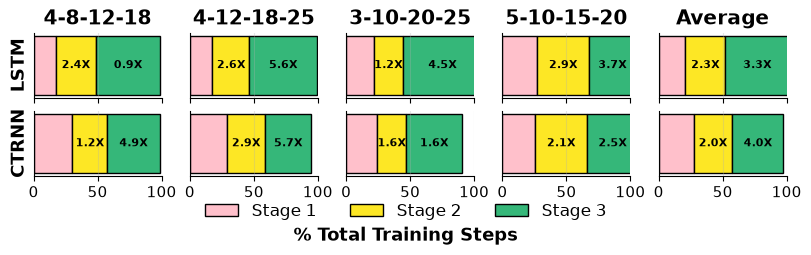

In [21]:
# plot for paper - aggregated across memory sizes within each architecture


results = {
    "LSTM125": min_training_timesteps125,
    "LSTM256": min_training_timesteps256,
    "CTRNN125": min_training_timestepsctrnn125,
    "CTRNN256": min_training_timestepsctrnn256,
}

max_training_ts = 1760000

colors = ["pink", "#FDE725", "#35B779"]

# =========================================================
# Collect per-run data
# =========================================================

training_timestep_rows = []

for model, model_results in results.items():

    architecture = model[:-3]
    memory_size = int(model[-3:])

    for anchor, runs_dict in model_results.items():

        for run, values in runs_dict.items():

            values = np.asarray(values, dtype=float)

            # Cumulative training timesteps -> duration of each stage
            learning_time = np.diff(
                np.insert(values, 0, 0)
            ).astype(float)

            # Mark invalid/negative durations as NaN
            learning_time[learning_time < 0] = np.nan

            # -------------------------------------------------
            # Percentage of total training for each stage
            # -------------------------------------------------

            stage_pct = (
                100 * learning_time / max_training_ts
            )

            # -------------------------------------------------
            # Fold increase relative to previous stage
            # -------------------------------------------------

            stage2_ratio = (
                learning_time[1] / learning_time[0]
                if learning_time[0] > 0 else np.nan
            )

            stage3_ratio = (
                learning_time[2] / learning_time[1]
                if ((learning_time[1] > 0)  and (values[2] < 1750000)  )
                    else np.nan
            )

            

            training_timestep_rows.append({
                "architecture": architecture,
                "memory_size": memory_size,
                "anchor": anchor,
                "run": run,
                "stage0": values[0],
                "stage1": values[1],
                "stage2": values[2],

                # Stage durations as % of total training
                "stage0_pct": stage_pct[0],
                "stage1_pct": stage_pct[1],
                "stage2_pct": stage_pct[2],

                # Fold increases
                "stage0-0": np.nan,
                "stage1-0": stage2_ratio,
                "stage2-1": stage3_ratio,
            })


training_timestep_df = pd.DataFrame(training_timestep_rows)


# =========================================================
# Calculate averages
# =========================================================

# Average across the 8 runs for each architecture × anchor
anchor_avg = (
    training_timestep_df
    .groupby(["architecture", "anchor"])
    [
        [
            "stage0_pct",
            "stage1_pct",
            "stage2_pct",
            "stage1-0",
            "stage2-1",
        ]
    ]
    .mean()
)

# Average across ALL runs, memory sizes and anchors
architecture_avg = (
    training_timestep_df
    .groupby("architecture")
    [
        [
            "stage0_pct",
            "stage1_pct",
            "stage2_pct",
            "stage1-0",
            "stage2-1",
        ]
    ]
    .mean()
)


# # Optional: inspect averages
# print("\nAverage across 8 runs for each architecture × anchor:")
# print(anchor_avg)

# print("\nAverage across all runs, memory sizes and anchors:")
# print(architecture_avg)


# =========================================================
# Plot
# =========================================================

architectures = ["LSTM", "CTRNN"]

# Preserve anchor order from the dataframe
anchors = list(
    training_timestep_df["anchor"].drop_duplicates()
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(anchors) + 1,
    figsize=(8, 2),
    sharex=True,
    constrained_layout=True,
)

if axes.ndim == 1:
    axes = axes.reshape(2, -1)


# =========================================================
# Architecture rows
# =========================================================

for row, architecture in enumerate(architectures):

    # -----------------------------------------------------
    # Individual anchor columns
    # -----------------------------------------------------

    for col, anchor in enumerate(anchors):

        ax = axes[row, col]

        means = anchor_avg.loc[
            (architecture, anchor)
        ]

        widths = [
            means["stage0_pct"],
            means["stage1_pct"],
            means["stage2_pct"],
        ]

        ratios = [
            np.nan,
            means["stage1-0"],
            means["stage2-1"],
        ]

        left = 0

        for stage, width in enumerate(widths):

            # Skip invalid values
            if np.isnan(width):
                continue

            ax.barh(
                0,
                width,
                left=left,
                color=colors[stage],
                edgecolor="black",
                linewidth=1,
                label=(
                    f"Stage {stage + 1}"
                    if row == 0 and col == 0
                    else None
                ),
            )

            # ---------------------------------------------
            # Display averaged fold increase
            # ---------------------------------------------

            if (
                stage > 0
                and not np.isnan(ratios[stage])
                and width > 0
            ):

                ax.text(
                    left + width / 2,
                    0,
                    f"{ratios[stage]:.1f}X",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                )

            left += width

        if row==0:
            ax.set_title(
                anchor,
                fontweight="bold",
            )

        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.grid(
            axis="x",
            alpha=0.3,
        )

        if col == 0:
            ax.set_ylabel(
                architecture,
                fontweight="bold",
            )


    # -----------------------------------------------------
    # Final column: overall architecture average
    # -----------------------------------------------------

    ax = axes[row, -1]

    means = architecture_avg.loc[architecture]

    widths = [
        means["stage0_pct"],
        means["stage1_pct"],
        means["stage2_pct"],
    ]

    ratios = [
        np.nan,
        means["stage1-0"],
        means["stage2-1"],
    ]

    left = 0

    for stage, width in enumerate(widths):

        if np.isnan(width):
            continue

        ax.barh(
            0,
            width,
            left=left,
            color=colors[stage],
            edgecolor="black",
            linewidth=1,
            label=(
                f"Stage {stage + 1}"
                if row == 0
                else None
            ),
        )

        # ---------------------------------------------
        # Display averaged fold increase
        # ---------------------------------------------

        if (
            stage > 0
            and not np.isnan(ratios[stage])
            and width > 0
        ):

            ax.text(
                left + width / 2,
                0,
                f"{ratios[stage]:.1f}X",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
            )

        left += width
        
    if row==0:
        ax.set_title(
            "Average",
            fontweight="bold",
        )

    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.grid(
        axis="x",
        alpha=0.3,
    )


# =========================================================
# Figure formatting
# =========================================================

fig.supxlabel(
    "% Total Training Steps",
    fontsize=13, y =-0.2,
    fontweight="bold",
)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

training_timestep_df= training_timestep_df[training_timestep_df["anchor"]!="Average"]

# plt.savefig("Scalability_multianchor.pdf", bbox_inches='tight')
plt.show()

In [50]:
training_timestep_df[["architecture","memory_size", "anchor", "stage2-1"]].groupby(["architecture"])["stage2-1"].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,14.0,3.965265,4.928098,0.187050,0.761364,1.605142,5.952387,17.791667
LSTM,6.0,3.328156,2.157970,0.642586,1.638263,3.421527,5.135354,5.732824


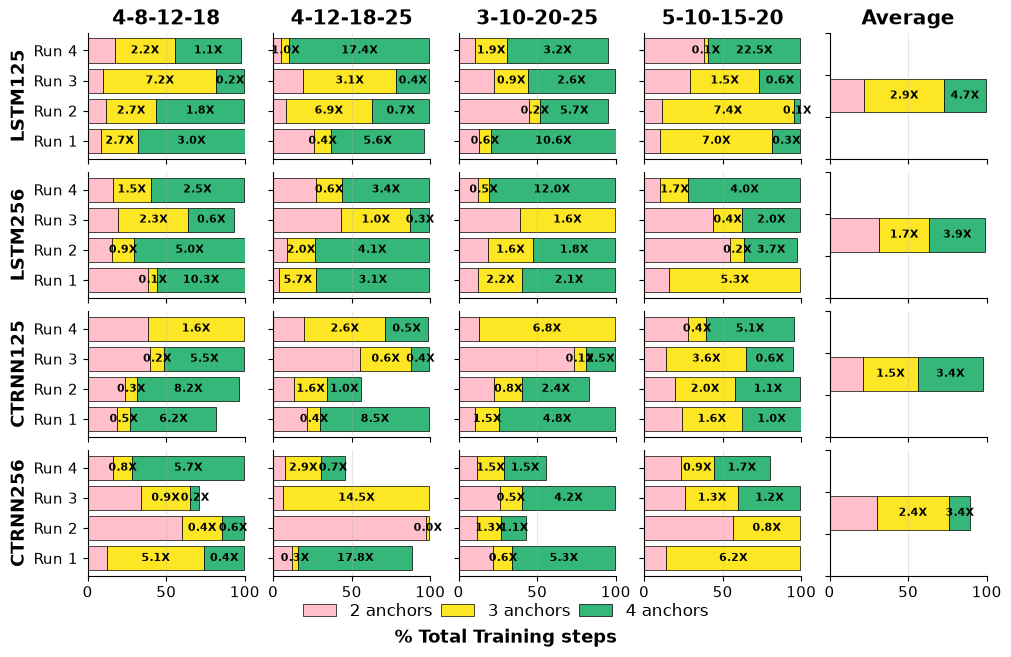

In [51]:
# supplementary 
# per run time steps visualization with average across runs and anchors  - for analysis 
# collect data for significance testing - architecure, size, anchor, run, stage 1, stage2-stage 1, 
results = {
    "LSTM125": min_training_timesteps125,
    "LSTM256": min_training_timesteps256,
    "CTRNN125": min_training_timestepsctrnn125,
    "CTRNN256": min_training_timestepsctrnn256,
}

training_timestep_rows = []


colors = ["pink", "#FDE725", "#35B779"]


models = list(results.keys())
anchors = list(results[models[0]].keys())

max_training_ts = 1760000  # <-- total training timesteps

fig, axes = plt.subplots(
    len(models),          # rows
    len(anchors) + 1,         # columns
    figsize=(10,6),
    squeeze=False,
    sharex=True,
    constrained_layout=True
)

for row, model in enumerate(models):

    for col, anchor in enumerate(anchors + ["Average"]):
        if anchor == "Average":
            ax=axes[row,len(anchors)]   
            left = 0
            y_avg = 1.5
            values = [np.mean([v for v in values_stages[s] if v != 0]) for s in range(3)]
            # perc_increase_avg = [np.nanmean([perc_increase_stages[s]]) for s in range(3)]

            avg = (
                     pd.DataFrame(training_timestep_rows)
                    .groupby(["architecture","memory_size"])[["stage1-0", "stage2-1", "stage3-2"]]
                    .mean()
                )
    
            model_arch = model[:-3]
            mem = int(model[-3:])
    
            perc_increase_avg = [
                np.nan,
                avg.loc[(model_arch, mem), "stage2-1"],
                avg.loc[(model_arch,mem), "stage3-2"]
            ]

            learning_time = np.diff(
                np.insert(values, 0, 0)
            ).astype(float)

            if learning_time[stage] < 0:
                learning_time[stage] = np.nan


                # Convert stage duration to percentage of total training
            widths_avg = [100 * learning_time[s] / max_training_ts for s in range(3)]
            # perc_increase_avg =  [learning_time[s] / learning_time[s-1] if s > 0 else np.nan for s in range(3)]
                    
            for s in range(3):    
                # plots average across runs  
                ax.barh(
                    y_avg,
                    widths_avg[s],
                    left=left,
                    color=colors[s],
                    edgecolor="black",
                    linewidth=0.5,
                    label=f"{s+2} anchors" if (row == 0 and col == 0) else None,
                )
                

                # Center of this bar segment
                x_text = (
                    left
                    + widths_avg[s] / 2
                )
                if (not np.isnan(perc_increase_avg[s]) and widths_avg[s] > 0) and (s>0) :
                    ax.text(
                        x_text,
                        y_avg,
                        f"{perc_increase_avg[s]:.1f}X",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="black"
                    )
                    
                left += widths_avg[s] # plots bar for one stage at a time. Hence left helps to keep a track of starting point for next cl stage.
          
    
        else:
            

            ax = axes[row, col]
    
            runs = sorted(results[model][anchor].keys())
            y = np.arange(len(runs))
    
            left = np.zeros(len(runs))
    
            values_stages = {
                0: [],
                1: [],
                2: []
            } 
    
            perc_increase_stages = {
                0: [],
                1: [],
                2: []
            } 
    
            for stage in range(3):
    
                widths = []  # width contaisn the % min_training time stage for a stage s for 4 runs -[run1_stage1_min, run2_stage1_min, run3_stage1_min,run4_stage1_min]
                perc_increase = [] # same as width but for % increase 
    
                for run in runs:
    
                    values = np.array(results[model][anchor][run])
                    values_stages[stage].append(values[stage])
    
                    learning_time = np.diff(
                        np.insert(values, 0, 0)
                    ).astype(float)
    
                    if learning_time[stage] < 0:
                        learning_time[stage] = np.nan
    
    
                    # Convert stage duration to percentage of total training
                    widths.append(100 * learning_time[stage] / max_training_ts)
                    
                    if stage >0:
                        perc_increase.append( learning_time[stage] / learning_time[stage-1])                    
                    else:
                        perc_increase.append(np.nan)
    
                    
                        
    
                if stage > 0:
                    perc_increase_stages[stage] = perc_increase
                else:
                    perc_increase_stages[stage] = widths # significance test - for stage one instead of xtimes previous stage, get % timesteps needed for stage 1 
    
    
    
                # plots one sub bar of the stacked barplot for a given stage for all 4 runs 
                ax.barh(
                    y,
                    widths,
                    left=left,
                    color=colors[stage],
                    edgecolor="black",
                    linewidth=0.5,
                    label=f"{stage+2} anchors" if (row == 0 and col == 0) else None,
                )
    
                for run_idx, (width, perc) in enumerate(
                    zip(widths, perc_increase)
                ):
    
                    if (
                        np.isnan(perc)
                        or width <= 0
                    ):
                        continue
    
                    # Center of this bar segment
                    x_text = (
                        left[run_idx]
                        + width / 2
                    )
    
                    ax.text(
                        x_text,
                        y[run_idx],
                        f"{perc:.1f}X",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="black"
                    )
    
    
                # Move starting point for next segment
                # left += np.nan_to_num(widths)
    
                left += np.nan_to_num(widths) # plots bar for one stage at a time. Hence left helps to keep a track of starting point for next cl stage. 

        ax.set_yticks(y)

        if col == 0:
            ax.set_yticklabels([f"Run {r}" for r in runs])
            ax.set_ylabel(model, fontweight="bold")
        else:
            ax.set_yticklabels([])

        if row == 0:
            ax.set_title(anchor, fontweight="bold")

        # if row == len(models) - 1:
        #     ax.set_xlabel("% Total Training")

        ax.set_xlim(0, 100)
        ax.grid(axis="x", alpha=0.3)

        for run in range(len(runs)):
            training_timestep_rows.append({"architecture":model[:-3], "memory_size":int(model[-3:]), "anchor":anchor, "run":run, 
                                           "stage0":values_stages[0][run], "stage1":values_stages[1][run], "stage2":values_stages[2][run],
                                           "stage1-0": perc_increase_stages[0][run], "stage2-1":perc_increase_stages[1][run], "stage3-2":perc_increase_stages[2][run]})

    
    

        

# axes[0, 0].legend(title="Curriculum stage", ncols=3, loc="lower center", )
fig.supxlabel("% Total Training steps", fontsize=13, y =-0.07, fontweight="bold")
# plt.tight_layout()
handles, labels_ = axes[0, 0].get_legend_handles_labels()

leg = fig.legend(
    handles,
    labels_ ,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(labels_),
    frameon=False,
    columnspacing=0.5
)

plt.savefig("Scalability_multianchor_supp.pdf", bbox_inches='tight')
        
plt.show()
# training_timestep_df = pd.DataFrame(training_timestep_rows)

# significant effect architecture, memory size, env config 

In [22]:

# significance test to check effect of env config, architecture, memory size, their interaction 
def overall_significance_test(training_timestep_df, colname, model_str=None ):
    anova_results = []

    df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
    # Make categorical variables explicit
    df["architecture"] = df["architecture"].astype("category")
    df["memory_size"] = df["memory_size"].astype("category")
    df["anchor"] = df["anchor"].astype("category")
    df = df.rename(columns={colname:"performance"})
    

    if model_str:
        model = smf.ols(model_str, data=df).fit()
    else:
        model = smf.ols(
        "performance ~ C(architecture)*C(memory_size) + C(anchor)",
        data=df).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("architecture effect",df.groupby("architecture")["performance"].agg(["count","mean", "std","median"]))
    print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))

    df["residual"] = model.resid
    res_125 = df[df["memory_size"] == 125]["residual"]
    res_256 = df[df["memory_size"] == 256]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")

    if p < 0.05:
        print("unequal variance so using cov_type=HC3")
        if model_str:
            model = smf.ols(model_str, data=df).fit(cov_type="HC3")
            
        else:            
            model = smf.ols(
                "performance ~ C(architecture) + C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")

       
    # print(sm.stats.anova_lm(model, typ=2))
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    anova_results.append(anova)
    return anova_results        

def archlevel_significance_test(training_timestep_df, colname ):
    anova_results = []
    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()
        # Make categorical variables explicit
        df["architecture"] = df["architecture"].astype("category")
        df["memory_size"] = df["memory_size"].astype("category")
        df["anchor"] = df["anchor"].astype("category")
        df = df.rename(columns={colname:"performance"})
        
    
        model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
            data=df
        ).fit()
    
        stat, p = shapiro(model.resid)
        print("Shapiro-Wilk:", stat, p)
        print("memory effect",df.groupby("memory_size")["performance"].agg(["count","mean", "std","median"]))
        print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))
    
        df["residual"] = model.resid
        res_125 = df[df["memory_size"] == 125]["residual"]
        res_256 = df[df["memory_size"] == 256]["residual"]
        
        stat, p = levene(res_125, res_256, center="median")
        
        print(f"Levene: W={stat:.3f}, p={p:.3f}")
    
        if p < 0.05:
            print("unequal variance so using cov_type=HC3")
            model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")
           
        # print(sm.stats.anova_lm(model, typ=2))
        anova = sm.stats.anova_lm(model, typ=2)
        # print(model.t_test("C(memory_size)[T.256]"))
        print(anova)
        anova_results.append(anova)
    return anova_results
    


In [23]:
# if normality is violated in the above old tests and anchor does not have significant effect in the overall test with n>25 
# use the following test to justify combining models within architecture 
def memory_within_arch(training_timestep_df, colname):

    # anova_results = []
    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()
        x1 = df[df["memory_size"]==125][colname]
        n_x = len(x1)
        y1 = df[df["memory_size"]==256][colname]
        n_y = len(y1)
        # get 
        

            # --- Normality check ---
        sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
        sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
        normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)
    
        # --- Homogeneity of variance check ---
        lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
        equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)
    
        if normal:
            stat, p = ttest_ind(x1, y1, equal_var=equal_var)
            test_used = "Welch's t-test" if not equal_var else "Student's t-test"
        else:
            # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
            try:
                stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
                test_used = "Mann-Whitney U"
            except ValueError:
                stat, p = np.nan, np.nan
                test_used = "Mann-Whitney U (failed, insufficient data)"

        print(test_used, "normality", normal, "equal variance", equal_var, stat, p)

In [24]:
def architecture_level_independent_test(significance_test_df, colname, first_arch=None):
    lstm, ctrnn = None, None
    for grp, data in significance_test_df.groupby("architecture"):
        if grp == "CTRNN":
            ctrnn = data[colname].dropna()
        if grp == "LSTM":
            lstm = data[colname].dropna()
    
    if first_arch == "ctrnn":
        arch_comparison_ordered = [ctrnn,lstm]
    elif first_arch == "lstm":
        arch_comparison_ordered = [lstm,ctrnn]
    else:
        raise ValueError("no arch order specified. provide an arch order for alternative = greater test")

        
    # --- Normality check (per group) ---
    sh_lstm_p = shapiro(lstm)[1] if len(lstm) >= 3 else np.nan
    sh_ctrnn_p = shapiro(ctrnn)[1] if len(ctrnn) >= 3 else np.nan
    normal = (not np.isnan(sh_lstm_p)) and (not np.isnan(sh_ctrnn_p)) and (sh_lstm_p > 0.05) and (sh_ctrnn_p > 0.05)
    print(f"Shapiro-Wilk: LSTM p={sh_lstm_p:.4f}, CTRNN p={sh_ctrnn_p:.4f}, normal={normal}")
    
    # --- Homogeneity of variance check ---
    lev_stat, lev_p = levene(lstm, ctrnn, center="median")
    equal_var = lev_p > 0.05
    print(f"Levene: stat={lev_stat:.3f}, p={lev_p:.4f}, equal_var={equal_var}")
    
    # --- Choose test based on assumptions ---
    if normal:
        t, p = ttest_ind(ctrnn, lstm, equal_var=equal_var, alternative="greater")
        test_used = "Welch's t-test" if not equal_var else "Student's t-test"
    else:
        # Fallback: Mann-Whitney U (non-parametric, independent samples)
        t, p = mannwhitneyu(ctrnn, lstm, alternative="greater")
        test_used = "Mann-Whitney U"
    
    print(f"Test used: {test_used}, stat={t:.3f}, p={p:.4f}")

In [25]:
# test if cl_ratio per model or architecture is more than 1x 
def cl_ratio_vs_1x(vals, alternative="greater"):
    vals = vals.dropna()
    n = len(vals)
    sh_p = shapiro(vals)[1] if n >= 3 else np.nan
    normal = (not np.isnan(sh_p)) and (sh_p > 0.05)

    if normal:
        stat, p = ttest_1samp(vals, popmean=1, alternative=alternative)
        test_used = "t-test"
    else:
        try:
            stat, p = wilcoxon(vals - 1, alternative=alternative)
            test_used = "Wilcoxon"
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = "Wilcoxon (failed, likely all-zero diffs)"

    return n, sh_p, normal, test_used, stat, p

In [26]:
training_timestep_df

,architecture,memory_size,anchor,run,stage0,stage1,stage2,stage0_pct,stage1_pct,stage2_pct,stage0-0,stage1-0,stage2-1
0,LSTM,125,4-8-12-18,1,152000.0,559000.0,1760000.0,8.636364,23.125000,68.238636,NaN,2.677632,NaN
1,LSTM,125,4-8-12-18,2,207000.0,761000.0,1752000.0,11.761364,31.477273,56.306818,NaN,2.676329,NaN
2,LSTM,125,4-8-12-18,3,176000.0,1436000.0,1750000.0,10.000000,71.590909,17.840909,NaN,7.159091,NaN
3,LSTM,125,4-8-12-18,4,306000.0,973000.0,1721000.0,17.386364,37.897727,42.500000,NaN,2.179739,1.121439
4,LSTM,125,4-12-18-25,1,459000.0,645000.0,1692000.0,26.079545,10.568182,59.488636,NaN,0.405229,5.629032
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,CTRNN,256,3-10-20-25,4,202000.0,510000.0,976000.0,11.477273,17.500000,26.477273,NaN,1.524752,1.512987
60,CTRNN,256,5-10-15-20,1,244000.0,1750000.0,0.0,13.863636,85.568182,NaN,NaN,6.172131,NaN
61,CTRNN,256,5-10-15-20,2,992000.0,1750000.0,0.0,56.363636,43.068182,NaN,NaN,0.764113,NaN
62,CTRNN,256,5-10-15-20,3,462000.0,1056000.0,1750000.0,26.250000,33.750000,39.431818,NaN,1.285714,NaN


# CL stage 0 (2-anchors)

In [45]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage0"] < 1750000) & (training_timestep_df["stage0"] >0)].copy()
colname = "stage0_pct"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count       mean        std     median
architecture memory_size                                        
CTRNN        125             16  27.123580  16.951685  22.187500
             256             16  27.269176  24.461253  18.977273
LSTM         125             16  17.816051  11.440403  12.301136
             256             16  23.696733  15.245967  17.130682
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.8350116836719341 5.922059320671379e-07
architecture effect               count       mean        std     median
architecture                                        
CTRNN            32  27.196378  20.702078  21.931818
LSTM             32  20.756392  13.591380  15.795455
anchor effect             count       mean        std     median
anchor                       

In [46]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
significance_test_df = training_timestep_df[(training_timestep_df["stage0"] < 1750000) & (training_timestep_df["stage0"] >0)].copy()
colname = "stage0_pct"
memory_within_arch(significance_test_df, colname)


LSTM
Mann-Whitney U normality False equal variance True 95.0 0.22061672997414716

CTRNN
Mann-Whitney U normality False equal variance True 148.0 0.46237974986725616


In [58]:
# is ctrnn significantly greater than lstm - in

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage0"] < 1750000) & (training_timestep_df["stage0"] >0)].copy()

colname = "stage0_pct"


architecture_level_independent_test(significance_test_df, colname, first_arch="ctrnn")

Shapiro-Wilk: LSTM p=0.0015, CTRNN p=0.0000, normal=False
Levene: stat=0.825, p=0.3672, equal_var=True
Test used: Mann-Whitney U, stat=624.500, p=0.0663


# CL stage 1-0

In [40]:
# basic tests to dcide if data can be merged within architectures and anchors 
# filter cases of non-convergence in stage 1
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])["stage1"].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage1_0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count           mean            std    median
architecture memory_size                                               
CTRNN        125             14  882357.142857  364072.817556  785000.0
             256             12  783083.333333  381639.158066  655000.0
LSTM         125             16  920750.000000  430817.594812  844500.0
             256             14  783928.571429  335219.208254  742000.0
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9002378787097965 0.0002230219398013758
architecture effect               count      mean       std    median
architecture                                     
CTRNN            26  1.259307  1.175103  0.849048
LSTM             30  2.221787  2.273480  1.547725
anchor effect             count      mean       std    median
an

In [41]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
colname = "stage1-0"
memory_within_arch(significance_test_df, colname)


LSTM
Mann-Whitney U normality False equal variance True 143.0 0.20483303385933527

CTRNN
Mann-Whitney U normality False equal variance True 73.0 0.5891544654500582


In [42]:
# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# is lstm significantly greater than ctrnn

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()

colname = "stage1-0"

architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.0000, CTRNN p=0.0002, normal=False
Levene: stat=3.762, p=0.0576, equal_var=True
Test used: Mann-Whitney U, stat=292.000, p=0.9472


In [43]:

# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# Is CL-efficiency ratio >1x ?
# LSTM showed a significant increase in training time relative to the previous CL stage (Wilcoxon, p=0.006), 
# while CTRNN did not (p=0.431). At the memory-size level, this LSTM effect was significant for LSTM125 (p=0.013)
# but not for LSTM256 (p=0.148); however, memory sizes did not differ significantly from each other within LSTM (Section X), 
# so this asymmetry should be interpreted cautiously rather than as evidence that only LSTM125 drives the effect.

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()

colname = "stage1-0"

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=26, shapiro_p=0.000, normal=False, test=Wilcoxon, stat=183.000, p=0.4306
LSTM: n=30, shapiro_p=0.000, normal=False, test=Wilcoxon, stat=353.000, p=0.0060

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 125): n=14, shapiro_p=0.035, normal=False, test=Wilcoxon, stat=55.000, p=0.4516
('CTRNN', 256): n=12, shapiro_p=0.001, normal=False, test=Wilcoxon, stat=40.000, p=0.4849
('LSTM', 125): n=16, shapiro_p=0.005, normal=False, test=Wilcoxon, stat=111.000, p=0.0125
('LSTM', 256): n=14, shapiro_p=0.003, normal=False, test=Wilcoxon, stat=70.000, p=0.1479


In [62]:
training_timestep_df.groupby("architecture")[["stage1-0"]].agg(["count","mean","std","median"])

stage1-0                              
                count      mean       std    median
architecture                                       
CTRNN              32  1.956267  2.844386  0.921917
LSTM               32  2.297923  2.269907  1.566607

# CL stage 2-1

In [47]:
# basic tests to dcide if data can be merged within architectures and anchors 
# filter cases of non-convergence in stage 1
colname = "stage2-1"
significance_test_df = training_timestep_df[(training_timestep_df["stage2"] < 1750000) & (training_timestep_df["stage2"] >0)].copy()

print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])["stage2"].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage1_0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count       mean            std     median
architecture memory_size                                            
CTRNN        125              8  1551000.0  258277.812774  1675000.0
             256              6  1126000.0  329801.152211  1114000.0
LSTM         125              4  1688000.0   24454.038521  1681500.0
             256              2  1676000.0   56568.542495  1676000.0
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.8931691953830876 0.03076596543566266
architecture effect               count      mean       std    median
architecture                                     
CTRNN            14  3.965265  4.928098  1.605142
LSTM              6  3.328156  2.157970  3.421527
anchor effect             count      mean       std    median
anchor                

In [48]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
significance_test_df = training_timestep_df[(training_timestep_df["stage2"] < 1750000) & (training_timestep_df["stage2"] >0)].copy()
colname = "stage2-1"
memory_within_arch(significance_test_df, colname)


LSTM
Mann-Whitney U normality False equal variance True 6.0 0.5333333333333333

CTRNN
Mann-Whitney U normality False equal variance True 29.0 0.5727605727605728


In [64]:
# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# is ctrnn significantly greater than lstm
colname = "stage2-1"
# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage2"] < 1750000) & (training_timestep_df["stage2"] >0)].copy()

architecture_level_independent_test(significance_test_df, colname, first_arch="ctrnn")

Shapiro-Wilk: LSTM p=0.3776, CTRNN p=0.0013, normal=False
Levene: stat=0.650, p=0.4306, equal_var=True
Test used: Mann-Whitney U, stat=37.000, p=0.6705


In [65]:

# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# Is CL-efficiency ratio >1x ?

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage2"] < 1750000) & (training_timestep_df["stage2"] >0)].copy()

colname = "stage2-1"

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=14, shapiro_p=0.001, normal=False, test=Wilcoxon, stat=75.000, p=0.0196
LSTM: n=6, shapiro_p=0.378, normal=True, test=t-test, stat=2.643, p=0.0229

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 125): n=8, shapiro_p=0.148, normal=True, test=t-test, stat=2.574, p=0.0184
('CTRNN', 256): n=6, shapiro_p=0.000, normal=False, test=Wilcoxon, stat=14.000, p=0.2812
('LSTM', 125): n=4, shapiro_p=0.326, normal=True, test=t-test, stat=2.648, p=0.0386
('LSTM', 256): n=2, shapiro_p=nan, normal=False, test=Wilcoxon, stat=2.000, p=0.5000


# Task performance

In [ ]:
# in task performance we need the best models of each anchor setting (2,3,4), so we take the last succesful timestep before switch and 
# for env2 we take the max training timestep

# performance visualization 

In [27]:
def multianchor_performance_across_runs(
    results_list,
    labels,
    n_anchors=None, fig_save = None
):

    delivery_values = [1, 2, 3, 4, -1]
    # cmap = plt.get_cmap("tab10")
    # colors_array = cmap(np.linspace(0, 1, 5))
    delivery_colors = {
        1: "#3B4CC0",   # deep blue
        2: "Pink",   # pink
        3: "#FDE725",   # yellow
        4: "#35B779", #green
        -1: "darkgrey",  # grey
    }
    delivery_labels = ["Delivery Counter 1", "Delivery Counter 2", "Delivery Counter 3", "Delivery Counter 4"]
    all_anchors = list(results_list[0].keys())
    
    if n_anchors is None:
        anchors = all_anchors
    else:
        anchors = [
            a for a in all_anchors
            if len(a.split("-")) == n_anchors
        ]

    # anchors = list(results_list[0].keys())[:n_anchors]

    fig, axes = plt.subplots(
        len(results_list),
        len(anchors),
        figsize=(9,6),
        # squeeze=False,
        sharey=True,
        constrained_layout=True
    )

    for r, (results, row_label) in enumerate(zip(results_list, labels)):

        for c, anchor in enumerate(anchors):

            ax = axes[r, c]

            log_ids = list(results[anchor].keys())

            td_keys = sorted({
                td
                for log_id in log_ids
                for td in results[anchor][log_id]
            })

            percentages = {v: [] for v in delivery_values}

            for td in td_keys:

                all_vals = []

                for log_id in log_ids:
                    if td in results[anchor][log_id]:
                        all_vals.extend(results[anchor][log_id][td])

                total = len(all_vals)

                for v in delivery_values:
                    percentages[v].append(
                        100 * all_vals.count(v) / total if total else 0
                    )

            bottom = np.zeros(len(td_keys))

            for v in delivery_values:
                ax.bar(
                    td_keys,
                    percentages[v],
                    bottom=bottom,
                    width=0.8,
                    color=delivery_colors[v],
                    # edgecolor="black",
                    linewidth=0.5,
                    label=str(v),
                )
                bottom += np.array(percentages[v])

            # Column titles = anchors
            if r == 0:
                ax.set_title(anchor, fontweight="bold")

            # Row labels
            if c == 0:
                ax.set_ylabel(f"{row_label}", fontweight="bold")


            ax.set_xticks(td_keys)
            # ax.set_xticklabels(td_keys, rotation=90)
            ax.set_xticklabels([str(td) if i % 2 == 0 else "" for i, td in enumerate(td_keys)], rotation=90)
            
    fig.supxlabel("Probe Duration", y = -0.1, fontsize=13, fontweight="bold")
    fig.supylabel("% Deliveries Across Runs",x=-0.02, fontsize=13, fontweight="bold")

    handles, labels_ = axes[0, 0].get_legend_handles_labels()

    # legend_title = Patch(
    # facecolor="none",
    # edgecolor="none",
    # label="Delivery Counters:"
    # )

    na_title = Patch(
    facecolor="darkgrey",
    edgecolor="darkgrey",
    label="Failed"
    )
    
    # leg = fig.legend(
    #     [legend_title] + handles[:n_anchors] + [na_title],
    #     ["Delivery Counters:"] + labels_[:n_anchors] + ["Failed"],
    #     loc="lower center",
    #     bbox_to_anchor=(0.5, -0.08),
    #     ncol=n_anchors + 2,
    #     frameon=False,
    #     columnspacing=0.5
    # )
    leg = fig.legend(
        handles[:n_anchors] + [na_title],
        delivery_labels[:n_anchors] + ["Failed"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=n_anchors + 2,
        frameon=False,
        columnspacing=0.5
    )

    # leg.get_texts()[0].set_weight("bold")
    fig.set_constrained_layout_pads(
    h_pad=0.05,
    hspace=0.05,
    w_pad=0.05,
    wspace=0.05,
    )
    if fig_save:
        plt.savefig(f"{fig_save}.pdf", bbox_inches='tight')
    # plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()

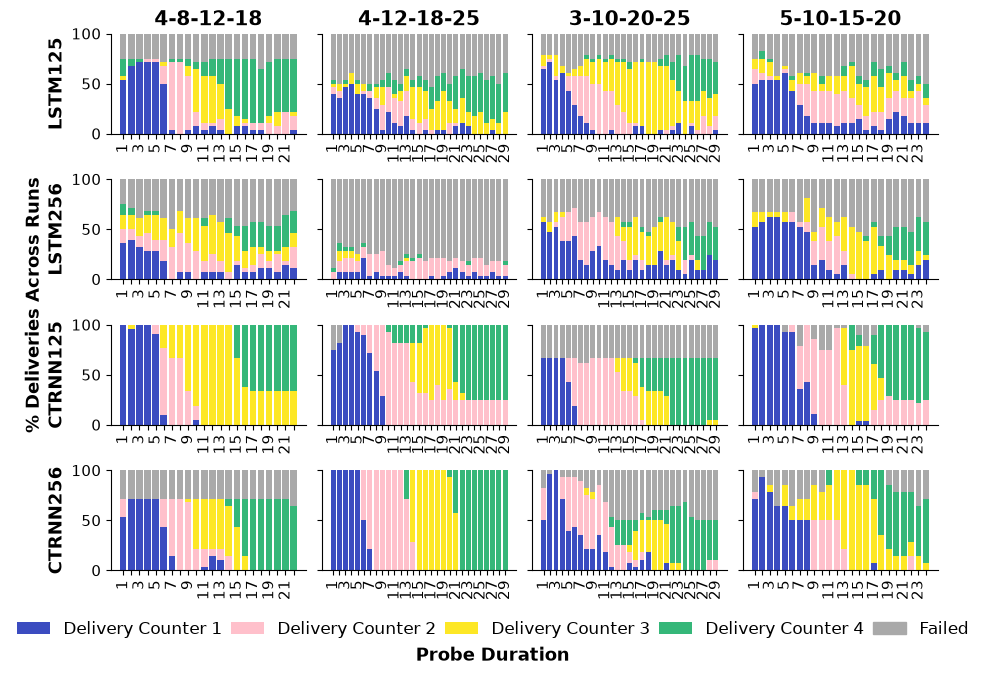

In [37]:
all_results = [delivery_counter_used_history125,delivery_counter_used_history256,delivery_counter_used_historyctrnn125, delivery_counter_used_historyctrnn256]
labels = ["LSTM125", "LSTM256", "CTRNN125", "CTRNN256"]

multianchor_performance_across_runs(all_results, labels, n_anchors=4, fig_save="chronocooked_4anchor")

In [ ]:
# for paper 

In [38]:
# # plot 3 and 4 anchors side by side


def plot_combined_multianchor(
    results_list,
    labels,
    fig_save=None
):


    delivery_values = [1, 2, 3, 4, -1]

    delivery_colors = {
        1: "#3B4CC0",
        2: "Pink",
        3: "#FDE725",
        4: "#35B779",
        -1: "darkgrey",
    }

    delivery_labels = [
        "Delivery Counter 1",
        "Delivery Counter 2",
        "Delivery Counter 3",
        "Delivery Counter 4"
    ]

    # =========================================================
    # 1 x 2 figure
    # =========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6),
        squeeze=False,
    )

    # =========================================================
    # Plot 3-anchor and 4-anchor cases
    # =========================================================

    for panel, n_anchors in enumerate([3, 4]):

        ax_all = axes[0, panel]

        all_anchors = list(results_list[0].keys())

        anchors = [
            a for a in all_anchors
            if len(a.split("-")) == n_anchors
        ]

        # -----------------------------------------------------
        # Each anchor gets its own subplot INSIDE this panel
        # -----------------------------------------------------

        # We cannot put multiple anchor plots into one ax.
        # Therefore create a nested GridSpec.
        

        # Remove the placeholder axis
        ax_all.remove()

        gs = GridSpecFromSubplotSpec(
            len(labels),
            len(anchors),
            subplot_spec=axes[0, panel].get_subplotspec(),
            wspace=0.02,
            hspace=0.30
        )

        nested_axes = np.empty(
            (len(labels), len(anchors)),
            dtype=object
        )

        for r in range(len(labels)):
            for c in range(len(anchors)):

                if c == 0:
                    nested_axes[r, c] = fig.add_subplot(
                        gs[r, c]
                    )
                else:
                    nested_axes[r, c] = fig.add_subplot(
                        gs[r, c],
                        sharey=nested_axes[r, 0]
                    )

        # -----------------------------------------------------
        # Plot
        # -----------------------------------------------------

        for r, (results, row_label) in enumerate(
            zip(results_list, labels)
        ):

            for c, anchor in enumerate(anchors):

                ax = nested_axes[r, c]

                log_ids = list(
                    results[anchor].keys()
                )

                td_keys = sorted({
                    td
                    for log_id in log_ids
                    for td in results[anchor][log_id]
                })

                percentages = {
                    v: []
                    for v in delivery_values
                }

                for td in td_keys:

                    all_vals = []

                    for log_id in log_ids:

                        if td in results[anchor][log_id]:

                            all_vals.extend(
                                results[anchor][log_id][td]
                            )

                    total = len(all_vals)

                    for v in delivery_values:

                        percentages[v].append(
                            100 * all_vals.count(v) / total
                            if total else 0
                        )

                bottom = np.zeros(
                    len(td_keys)
                )

                for v in delivery_values:

                    ax.bar(
                        td_keys,
                        percentages[v],
                        bottom=bottom,
                        width=0.8,
                        color=delivery_colors[v],
                        linewidth=0.5
                    )

                    bottom += np.asarray(
                        percentages[v]
                    )

                # -------------------------------------------------
                # Anchor title
                # -------------------------------------------------

                if r == 0:

                    ax.set_title(
                        anchor,
                        fontweight="bold",
                        
                    )

                # -------------------------------------------------
                # Model label
                # -------------------------------------------------
                
                if panel == 0 and c == 0:
                    # Only first column of first panel
                    ax.set_ylabel(
                        row_label,
                        fontweight="bold", fontsize=12,
                    )
                
                    ax.tick_params(
                        axis="y",
                        labelleft=True
                    )
                
                elif panel == 0:
                    # Other columns in first panel:
                    # hide y tick labels
                    ax.tick_params(
                        axis="y",
                        labelleft=False
                    )
                
                else:
                    # Entire second panel:
                    # hide y tick labels
                    ax.tick_params(
                        axis="y",
                        labelleft=False
                    )
                
                # if c == 0:

                #     ax.set_ylabel(
                #         row_label,
                #         fontweight="bold"
                #     )


                # else:

                #     ax.set_yticklabels([])

                # -------------------------------------------------
                # X axis
                # -------------------------------------------------

                # ax.set_xticks(td_keys)

                # ax.set_xticklabels(
                #     [
                #         str(td)
                #         if i % 2 == 0
                #         else ""
                #         for i, td in enumerate(td_keys)
                #     ],
                #     rotation=90
                # )

                ax.set_xticks(td_keys)

                if r == len(labels) - 1:
                    # Show x-axis labels only on the last row
                    ax.set_xticklabels(
                        [
                            str(td) if i % 4 == 0 else ""
                            for i, td in enumerate(td_keys)
                        ],
                        rotation=90
                    )
                else:
                    # Hide x-axis tick labels for all other rows
                    ax.set_xticklabels([])

                ax.grid(
                    axis="y",
                    alpha=0.3
                )

        # -----------------------------------------------------
        # Panel title
        # -----------------------------------------------------

        # Put title above the entire group
        panel_axes = nested_axes.flatten()

        left = panel_axes[0].get_position().x0
        right = panel_axes[-1].get_position().x1
        top = max(
            ax.get_position().y1
            for ax in panel_axes
        )

        fig.text(
            (left + right) / 2,
            top + 0.1,
            f"{n_anchors}-anchor",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=13
        )

    # =========================================================
    # Shared labels
    # =========================================================

    fig.supxlabel(
        "Probe Duration",
        fontweight="bold",
        y=-0.08
    )

    fig.supylabel(
        "% Deliveries Across Runs",
        fontweight="bold",
        x=0
    )

    # =========================================================
    # Shared legend
    # =========================================================

    handles = [
        Patch(
            facecolor=delivery_colors[v],
            label=delivery_labels[v - 1]
        )
        for v in range(1, 5)
    ]

    handles.append(
        Patch(
            facecolor=delivery_colors[-1],
            label="Failed"
        )
    )

    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=5,
        frameon=False,
        columnspacing=1.0
    )

    # =========================================================
    # Layout
    # =========================================================

    plt.subplots_adjust(
        left=0.07,
        right=0.99,
        top=0.92,
        bottom=0.09,
        wspace=0.05
    )

    if fig_save is not None:

        plt.savefig(
            f"{fig_save}.pdf",
            bbox_inches="tight"
        )

    plt.show()

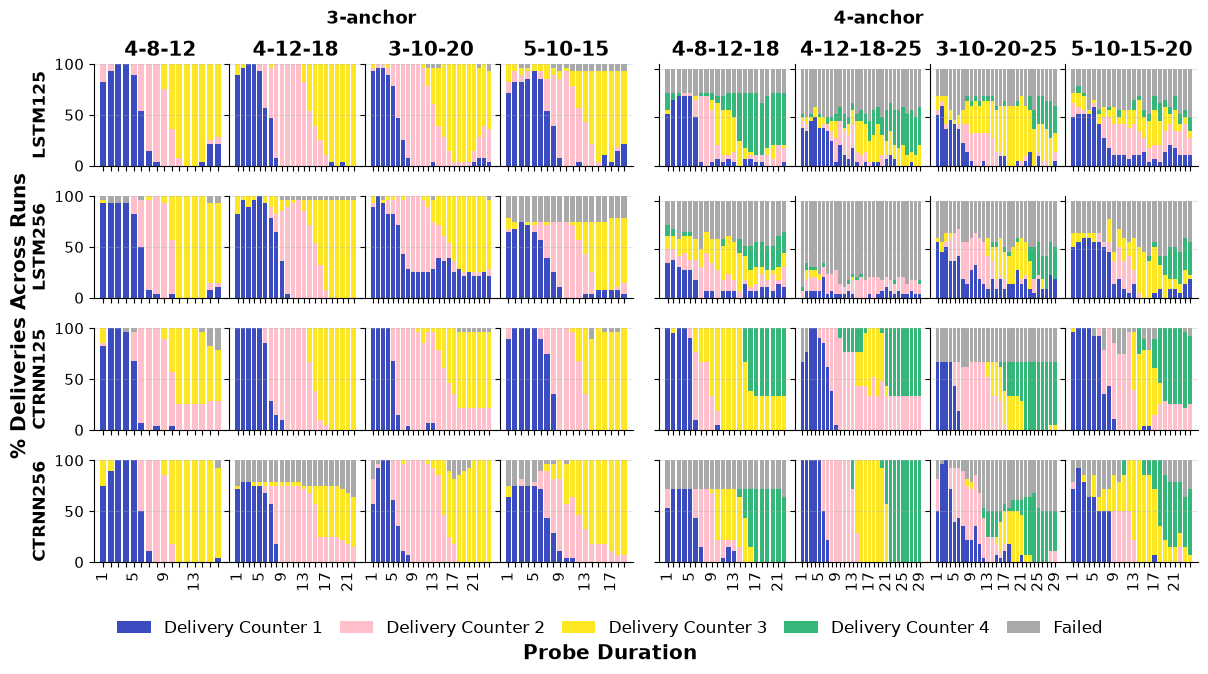

In [39]:
# for paper get 3 and 4 anchor task performance side by side
all_results = [
    delivery_counter_used_history125,
    delivery_counter_used_history256,
    delivery_counter_used_historyctrnn125,
    delivery_counter_used_historyctrnn256
]

labels = [
    "LSTM125",
    "LSTM256",
    "CTRNN125",
    "CTRNN256"
]

plot_combined_multianchor(
    all_results,
    labels,
    fig_save="chronocooked_3_vs_4_anchor"
)

# Quantify task performance

In [28]:
# sepate calculation for each run - % incorrect deliveryies across seeds and probe durations within a categpry. 
# combined case has 4*4 total runs - taken across main anchors
# each main anchor has 4 runs 

all_results = [
    delivery_counter_used_history125,
    delivery_counter_used_history256,
    delivery_counter_used_historyctrnn125,
    delivery_counter_used_historyctrnn256
]

labels = [
    "LSTM125",
    "LSTM256",
    "CTRNN125",
    "CTRNN256"
]


# =========================================================
# Main anchors
# =========================================================

main_anchors = [
    (4, 8, 12, 18),
    (4, 12, 18, 25),
    (3, 10, 20, 25),
    (5, 10, 15, 20)

]


# Convert main anchors to strings for dictionary keys
main_anchor_strings = [
    "-".join(map(str, ma))
    for ma in main_anchors
]


# =========================================================
# Store results separately for each model
#
# interval_results[model][n_anchors][run_name] - adede run name for paired comparison 
#
# interval_results_detailed[model][main_anchor][n_anchors]
# =========================================================

interval_results = {
    model: defaultdict(list)
    for model in labels
}


interval_results_detailed = {
    model: {
        main_anchor_str: {}
        for main_anchor_str in main_anchor_strings
    }
    for model in labels
}


# =========================================================
# Loop over models
# =========================================================

for model, results in zip(labels, all_results):

    print(f"\nProcessing {model}")

    # -----------------------------------------------------
    # Loop over anchor cases
    # -----------------------------------------------------

    for anchor_case, runs in results.items():

        anchor_values = tuple(
            map(int, anchor_case.split("-"))
        )

        n_anchors = len(anchor_values)


        # -------------------------------------------------
        # Find corresponding main anchor
        #
        # Example:
        #
        # 4-8       -> 4-8-12-18
        # 4-8-12    -> 4-8-12-18
        # -------------------------------------------------

        matching_main_anchor = next(
            (
                ma
                for ma in main_anchors
                if (
                    len(anchor_values) <= len(ma)
                    and all(
                        anchor_values[i] == ma[i]
                        for i in range(len(anchor_values))
                    )
                )
            ),
            None
        )


        # -------------------------------------------------
        # No matching main anchor
        # -------------------------------------------------

        if matching_main_anchor is None:

            print(
                f"Could not find main anchor "
                f"for {anchor_case}"
            )

            continue


        # -------------------------------------------------
        # IMPORTANT:
        # Convert tuple -> string
        #
        # This is now the dictionary key
        # -------------------------------------------------

        main_anchor = "-".join(
            map(str, matching_main_anchor)
        )


        # -------------------------------------------------
        # Loop over runs
        # -------------------------------------------------

        for run_name, td_dict in runs.items():

            if len(td_dict) == 0:
                continue


            # -------------------------------------------------
            # Target-duration keys
            # -------------------------------------------------

            td_keys = [
                td
                for td in range(
                    1,
                    anchor_values[-1] + 5
                )
            ]


            interval_errors = []


            # -------------------------------------------------
            # Calculate error for each interval
            #
            # i = 0:
            #     before first anchor
            #
            # i = 1 ... n-1:
            #     between anchors
            #
            # i = n:
            #     after final anchor
            # -------------------------------------------------

            for i in range(n_anchors + 1): # iterate through probe categories

                incorrect = 0
                total = 0


                for td in td_keys:

                    if i == 0: # Before first anchor - first category

                        if td >= anchor_values[0]:
                            continue

                        allowed = {  
                            1,
                            -1
                        } # allowed delivery counter and exclude failed cases 


                    elif i == n_anchors:  # After final anchor - last category 

                        if td < anchor_values[-1]:
                            continue

                        allowed = {
                            n_anchors,
                            -1
                        }  # allowed delivery counter and exclude failed cases 


                    else: # Between anchors - inbetween categories 

                        if not (
                            anchor_values[i - 1]
                            <= td
                            < anchor_values[i]
                        ):
                            continue

                        allowed = {
                            i,
                            i + 1,
                            -1
                        }  # allowed delivery counters and exclude failed cases 


                    # -----------------------------------------
                    # Get values
                    # -----------------------------------------

                    if td not in td_dict:
                        continue

                    vals = td_dict[td] 


                    # -----------------------------------------
                    # Count incorrect responses
                    #
                    # -1 is excluded from total
                    # -----------------------------------------

                    incorrect += sum(
                        v not in allowed
                        for v in vals
                    )  # sumed for a category 

                    total += sum(
                        v != -1
                        for v in vals
                    )


                # ---------------------------------------------
                # Error rate of a category across seed*td of a category for a given model, anchor and run 
                # ---------------------------------------------

                if total > 0:

                    error_rate = (
                        incorrect / total
                    )

                else:

                    error_rate = np.nan


                interval_errors.append(
                    error_rate
                )  # append error rate for each category 


            # =================================================
            # Store detailed result - store the percenatge of incorrect deliveries calculated witing a category for each run 
            # =================================================

            if n_anchors not in (
                interval_results_detailed[
                    model
                ][main_anchor]
            ):

                interval_results_detailed[
                    model
                ][main_anchor][n_anchors] = []


            interval_results_detailed[
                model
            ][main_anchor][n_anchors].append(
                interval_errors
            ) # [num of categories] * number of runs for each anchor so len = 4 


            # =================================================
            # Store grouped result
            # =================================================

            interval_results[
                model
            ][n_anchors].append({f"{main_anchor}-run{run_name.split("-")[0]}":
                interval_errors
                           })  # [num of categories] * number of runs - across anchors so len = 4*4


# =========================================================
# Inspect
# =========================================================

print(
    interval_results["LSTM125"]
)


# print(
#     interval_results_detailed[
#         "LSTM125"
#     ]["4-8-12-18"]
# )


Processing LSTM125

Processing LSTM256

Processing CTRNN125

Processing CTRNN256
defaultdict(<class 'list'>, {2: [{'4-8-12-18-run1': [0.0, 0.0, 0.0]}, {'4-8-12-18-run2': [0.0, 0.0, 0.0]}, {'4-8-12-18-run3': [0.0, 0.0, 0.0]}, {'4-8-12-18-run4': [0.0, 0.0, 0.0]}, {'4-12-18-25-run1': [0.19047619047619047, 0.0, 0.0]}, {'4-12-18-25-run2': [0.0, 0.0, 0.0]}, {'4-12-18-25-run3': [0.0, 0.0, 0.0]}, {'4-12-18-25-run4': [0.0, 0.0, 0.08571428571428572]}, {'3-10-20-25-run1': [0.0, 0.0, 0.0]}, {'3-10-20-25-run2': [0.0, 0.0, 0.0]}, {'3-10-20-25-run3': [0.0, 0.0, 0.0]}, {'3-10-20-25-run4': [0.14285714285714285, 0.0, 0.0]}, {'5-10-15-20-run1': [0.03571428571428571, 0.0, 0.0]}, {'5-10-15-20-run2': [0.07142857142857142, 0.0, 0.0]}, {'5-10-15-20-run3': [0.0, 0.0, 0.05714285714285714]}, {'5-10-15-20-run4': [0.03571428571428571, 0.0, 0.05714285714285714]}], 3: [{'4-8-12-18-run1': [0.0, 0.0, 0.0, 0.05714285714285714]}, {'4-8-12-18-run2': [0.0, 0.0, 0.0, 0.11428571428571428]}, {'4-8-12-18-run3': [0.0, 0.0, 0.

In [ ]:
# For a given model and anchor setting with n anchor = n 
# first calculte % incorrect deliveries across seeds for each td 
# in a given probe duration category collect all % of each td. so interval_results_detailed["LSTM125"]["4-8-12-18"]) = hs each list of len 5 - number of tds in a cat
# 

In [101]:
np.asarray(
                detailed[4],
                dtype=float
)

array([[0.11764706, 0.88888889, 0.0625    , 0.03030303, 0.64705882],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

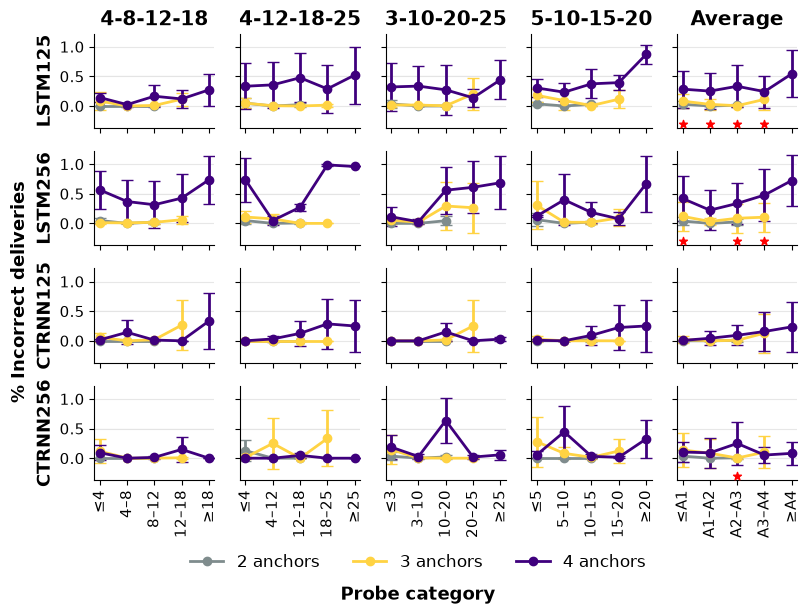

In [83]:
# plot task performance for paper 

colors = {
    4: "#3F007D",   # dark purple
    3: "#FFD343",   # orange
    2: "#7F8C8D",   # grey
}

category_labels = {0:"<=A1",1:"A1-A2",2:"A2-A3",3:"A3-A4",4:">=A4"}
# ---------------------------------------------------------
# Models
# ---------------------------------------------------------

models = list(interval_results.keys())

main_anchors = [
    (4, 8, 12, 18),
        (4, 12, 18, 25),
    (3, 10, 20, 25),
    (5, 10, 15, 20)

]


# ---------------------------------------------------------
# Convert main anchors to strings
#
# These are the actual keys in interval_results_detailed
# ---------------------------------------------------------

main_anchor_strings = [
    "-".join(map(str, anchor))
    for anchor in main_anchors
]


# ---------------------------------------------------------
# Figure
#
# rows    = models
# columns = 4 main anchors + average performance
# ---------------------------------------------------------

n_models = len(models)
n_main_anchors = len(main_anchor_strings)

fig, axes = plt.subplots(
    n_models,
    n_main_anchors + 1,
    figsize=(8, 6),
    squeeze=False,
    sharey=True
)


# ---------------------------------------------------------
# Plot main-anchor panels
# ---------------------------------------------------------

for row, model in enumerate(models):

    for col, main_anchor_str in enumerate(main_anchor_strings):

        ax = axes[row, col]


        # -------------------------------------------------
        # Check that this main anchor exists
        # -------------------------------------------------

        if (
            model not in interval_results_detailed
            or main_anchor_str not in interval_results_detailed[model]
        ):

            ax.axis("off")
            continue


        detailed = interval_results_detailed[
            model
        ][main_anchor_str]


        # -------------------------------------------------
        # Plot different numbers of anchors
        # -------------------------------------------------

        for n_anchor in sorted(detailed.keys()):

            vals = np.asarray(
                detailed[n_anchor],
                dtype=float
            )  # vals = number of categories * runs 

            if vals.size == 0:
                continue


            mean = np.nanmean(
                vals,
                axis=0
            ) # mean across runs for a given category 

            std = np.nanstd(
                vals,
                axis=0
            )


            x = np.arange(
                len(mean)
            )


            ax.errorbar(
                x,
                mean,
                yerr=std,
                marker="o",
                capsize=4,
                linewidth=2,
                color=colors[n_anchor],
                label=f"{n_anchor} anchors"
            )


        # -------------------------------------------------
        # X labels
        # -------------------------------------------------

        anchors = list(
            map(
                int,
                main_anchor_str.split("-")
            )
        )


        labels = [
            f"≤{anchors[0]}",
            f"{anchors[0]}–{anchors[1]}",
            f"{anchors[1]}–{anchors[2]}",
            f"{anchors[2]}–{anchors[3]}",
            f"≥{anchors[3]}"
        ]


        ax.set_xticks(
            np.arange(len(labels))
        )

        if row == n_models -1:
            ax.set_xticklabels(
                labels,
                rotation=90
            )
        else:
            ax.set_xticklabels([])


        # -------------------------------------------------
        # Titles
        # -------------------------------------------------

        if row == 0:

            ax.set_title(
                main_anchor_str,
                fontweight="bold"
            )


        # -------------------------------------------------
        # Model label
        # -------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                model,
                fontweight="bold"
            )


        # ax.set_xlabel(
        #     "Anchor interval"
        # )


        ax.grid(
            axis="y",
            alpha=0.3
        )
        ax.axhline(0.5, linestyle="-", color="grey", linewidth=0.1 ,alpha=0.3)
        ax.set_yticks([0, 0.5, 1])


# =========================================================
# Average-performance column
# =========================================================

for row, model in enumerate(models):

    ax = axes[row, -1]


    # -----------------------------------------------------
    # Collect all interval results across main anchors
    # -----------------------------------------------------

    # average_data = {}


    # for main_anchor_str in main_anchor_strings:

    #     if (
    #         model not in interval_results_detailed
    #         or main_anchor_str not in interval_results_detailed[model]
    #     ):
    #         continue


    #     detailed = interval_results_detailed[
    #         model
    #     ][main_anchor_str]


    #     for n_anchor, values in detailed.items():

    #         values = np.asarray(
    #             values,
    #             dtype=float
    #         )


    #         if values.size == 0:
    #             continue


    #         if n_anchor not in average_data:

    #             average_data[n_anchor] = []


    #         # Add all runs from this main anchor
    #         average_data[n_anchor].append(
    #             values
    #         )


    # -----------------------------------------------------
    # Plot average for each number of anchors
    # -----------------------------------------------------

    for n_anchor in interval_results[model].keys():


        # Combine all runs from all main anchors
        vals = [v for vals_dict in interval_results[model][n_anchor]
               for k, v in vals_dict.items()] # 16 runs taken across all main anchors with erro rate for each probe category 


        mean = np.nanmean(
            vals,
            axis=0
        )

        std = np.nanstd(
            vals,
            axis=0
        )


        x = np.arange(
            len(mean)
        )


        ax.errorbar(
            x,
            mean,
            yerr=std,
            marker="o",
            capsize=4,
            linewidth=2,
            color=colors[n_anchor],
            label=f"{n_anchor} anchors"
        )

    # -----------------------------------------------------
    # Test 4 anchors vs 3 anchors
    # -----------------------------------------------------

    # vals_3 = np.asarray(
    #     interval_results[model][3],
    #     dtype=float
    # )

    # vals_4 = np.asarray(
    #     interval_results[model][4],
    #     dtype=float
    # )

    # Test only the 4 probe categories shared by 3 and 4
    for category in range(4):
        # runs = len(vals_4[:, category])  # ideally remove this with new runs 
        # x3 = vals_3[:runs, category]
        # x4 = vals_4[:runs, category]

        # # Pairwise removal of NaNs
        # mask = ~np.isnan(x3) & ~np.isnan(x4)

        # t, p = ttest_rel(
        #     x4[mask],
        #     x3[mask],
        #     alternative="greater"   # 4 > 3, null 4<=3
        # )

        # -------------------------------------------------
        # Red dot if significant
        # -------------------------------------------------
        p = [cl_comp_model["p_holm"] for cl_comp_model in cl_comparison_results[model] 
             if cl_comp_model["category"]==category_labels[category]][0]
        if p < 0.05:

            # Put dot slightly above the 4-anchor mean
            # y = np.nanmean(x4)

            ax.scatter(
                category,
                -0.3,
                color="red",
                s=35,
                marker="*",
                zorder=10
            )

    # -----------------------------------------------------
    # Average column formatting
    # -----------------------------------------------------

    if row == 0:

        ax.set_title(
            "Average",
            fontweight="bold"
        )


    ax.set_xticks(
        np.arange(5)
    )


    if row==n_models-1:
        ax.set_xticklabels(
            [
                "≤A1",
                "A1–A2",
                "A2–A3",
                "A3–A4",
                "≥A4"
            ],
            rotation=90
        )
    else:
        ax.set_xticklabels([])


    # ax.set_xlabel(
    #     "Anchor interval"
    # )


    ax.grid(
        axis="y",
        alpha=0.3
    )


# =========================================================
# One shared legend at bottom
# =========================================================

handles = [
    plt.Line2D(
        [],
        [],
        color=colors[n],
        marker="o",
        linewidth=2,
        label=f"{n} anchors"
    )
    for n in sorted(colors)
]


fig.legend(
    handles=handles,
    labels=[
        f"{n} anchors"
        for n in sorted(colors)
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(handles),
    frameon=False
)


# =========================================================
# Layout
# =========================================================

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

fig.supxlabel(
    "Probe category",
    fontsize=13, y = -0.02,
    fontweight="bold"
)

fig.supylabel(
    "% Incorrect deliveries",
    fontsize=13,
    fontweight="bold", x=-0.01
)
plt.savefig(
    "multianchor_task_performance_supp.pdf",
    bbox_inches="tight"
)


plt.show()

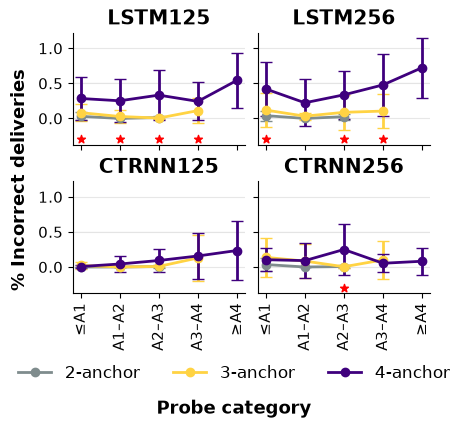

In [86]:
# average 
# plot task performance for paper 

colors = {
    4: "#3F007D",   # dark purple
    3: "#FFD343",   # orange
    2: "#7F8C8D",   # grey
}

# ---------------------------------------------------------
# Models
# ---------------------------------------------------------
category_labels = {0:"<=A1",1:"A1-A2",2:"A2-A3",3:"A3-A4",4:">=A4"}

models = list(interval_results.keys())

main_anchor_strings = [
    "-".join(map(str, anchor))
    for anchor in main_anchors
]

n_rows=2
n_cols=2
n_models = len(models)
n_main_anchors = len(main_anchor_strings)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4,3.5),
    squeeze=False,
    sharey=True,
    constrained_layout=True
)



# =========================================================
# Average-performance column
# =========================================================

for i, model in enumerate(models):

    row = i // n_cols
    col = i % n_cols

    ax = axes[row, col]


    for n_anchor in interval_results[model].keys():


        # Combine all runs from all main anchors
        # vals = interval_results[model][n_anchor] # 16 runs taken across all main anchors with erro rate for each probe category 
        vals = [v for vals_dict in interval_results[model][n_anchor]
                       for k, v in vals_dict.items()] # 16 runs taken across all main anchors with erro rate for each probe category 


        mean = np.nanmean(
            vals,
            axis=0
        )

        std = np.nanstd(
            vals,
            axis=0
        )


        x = np.arange(
            len(mean)
        )


        ax.errorbar(
            x,
            mean,
            yerr=std,
            marker="o",
            capsize=4,
            linewidth=2,
            color=colors[n_anchor],
            label=f"{n_anchor} anchors"
        )

    # -----------------------------------------------------
    # Test 4 anchors vs 3 anchors
    # -----------------------------------------------------

    # vals_3 = np.asarray(
    #     interval_results[model][3],
    #     dtype=float
    # )

    # vals_4 = np.asarray(
    #     interval_results[model][4],
    #     dtype=float
    # )

    # Test only the 4 probe categories shared by 3 and 4
    for category in range(4):
        # runs = len(vals_4[:, category])  # ideally remove this with new runs 
        # x3 = vals_3[:runs, category]
        # x4 = vals_4[:runs, category]

        # # Pairwise removal of NaNs
        # mask = ~np.isnan(x3) & ~np.isnan(x4)

        # t, p = ttest_rel(
        #     x4[mask],
        #     x3[mask],
        #     alternative="greater"   # 4 > 3, null 4<=3
        # )

        # -------------------------------------------------
        # Red dot if significant
        # -------------------------------------------------
        p = [cl_comp_model["p_holm"] for cl_comp_model in cl_comparison_results[model] 
             if cl_comp_model["category"]==category_labels[category]][0]

        if p < 0.05:

            # Put dot slightly above the 4-anchor mean
            # y = np.nanmean(x4)

            ax.scatter(
                category,
                -0.3,
                color="red",
                s=35,
                marker="*",
                zorder=10
            )

    # -----------------------------------------------------
    # Average column formatting
    # -----------------------------------------------------

    # if row == 0:

        # ax.set_title(
        #     "Average",
        #     fontweight="bold"
        # )


    ax.set_xticks(
        np.arange(5)
    )


    if row==1:
        ax.set_xticklabels(
            [
                "≤A1",
                "A1–A2",
                "A2–A3",
                "A3–A4",
                "≥A4"
            ],
            rotation=90
        )
    else:
        ax.set_xticklabels([])


    # ax.set_xlabel(
    #     "Anchor interval"
    # )


    ax.grid(
        axis="y",
        alpha=0.3
    )
    ax.axhline(0.5, linestyle="-", color="grey", linewidth=0.1 ,alpha=0.3)
    ax.set_yticks([0, 0.5, 1])
         

    ax.set_title(
        model,
        fontweight="bold"
    )



# =========================================================
# One shared legend at bottom
# =========================================================

handles = [
    plt.Line2D(
        [],
        [],
        color=colors[n],
        marker="o",
        linewidth=2,
        label=f"{n} anchors"
    )
    for n in sorted(colors)
]


fig.legend(
    handles=handles,
    labels=[
        f"{n}-anchor"
        for n in sorted(colors)
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)


# =========================================================
# Layout
# =========================================================

# plt.tight_layout(
#     rect=[0, 0.06, 1, 1]
# )

fig.supxlabel(
    "Probe category",
    fontsize=13, y = -0.18,
    fontweight="bold"
)

fig.supylabel(
    "% Incorrect deliveries",
    fontsize=13,
    fontweight="bold", x=-0.06
)
plt.savefig(
    "multianchor_task_performance_avg.pdf",
    bbox_inches="tight"
)


plt.show()

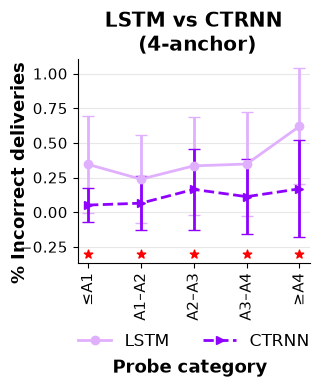

In [146]:
# plot architecture level task performance

# ---------------------------------------------------------
# Plot anchor-4 performance: LSTM vs CTRNN
# ---------------------------------------------------------

architectures = ["LSTM", "CTRNN"]

fig, ax = plt.subplots(figsize=(3,3))

for arch in architectures:

    # Combine both memory sizes
    # vals = np.concatenate(
    #     [
    #         np.asarray(interval_results[model][4], dtype=float)
    #         for model in interval_results
    #         if model[:-3] == arch
    #     ],
    #     axis=0
    # )

    vals = np.concatenate(
        [
            np.asarray(
                [v for vals_dict in interval_results[model][4]
                 for k, v in vals_dict.items()],
                dtype=float
            )
            for model in interval_results.keys()
            if model[:-3] == arch
        ],
        axis=0
    )


    mean = np.nanmean(vals, axis=0)
    std = np.nanstd(vals, axis=0)

    x = np.arange(5)

    ax.errorbar(
        x,
        mean,
        yerr=std,
        capsize=4,
        linewidth=2,
        marker="o" if arch == "LSTM" else ">",
        # color="#3F007D",
        linestyle="-" if arch == "LSTM" else "--",
        color="#E0B0FF" if arch == "LSTM" else "#8F00FF",
        label=arch
    )
# ---------------------------------------------------------
# ANOVA: LSTM vs CTRNN
# ---------------------------------------------------------

for arch1, arch2 in [("LSTM", "CTRNN")]:

    # vals_1 = np.concatenate(
    #     [
    #         np.asarray(interval_results[model][4], dtype=float)
    #         for model in interval_results.keys()
    #         if model[:-3] == arch1
    #     ],
    #     axis=0
    # )

    # vals_2 = np.concatenate(
    #     [
    #         np.asarray(interval_results[model][4], dtype=float)
    #         for model in interval_results.keys()
    #         if model[:-3] == arch2
    #     ],
    #     axis=0
    # )

    
    # vals_1 = np.concatenate(
    #     [
    #         np.asarray(
    #             [v for vals_dict in interval_results[model][4]
    #              for k, v in vals_dict.items()],
    #             dtype=float
    #         )
    #         for model in interval_results.keys()
    #         if model[:-3] == arch1
    #     ],
    #     axis=0
    # )

    # vals_2 = np.concatenate(
    #     [
    #         np.asarray(
    #             [v for vals_dict in interval_results[model][4]
    #              for k, v in vals_dict.items()],
    #             dtype=float
    #         )
    #         for model in interval_results.keys()
    #         if model[:-3] == arch2
    #     ],
    #     axis=0
    # )

    for category in range(5):
        # runs = min(len(vals_1[:, category]), len(vals_2[:, category])) # ideally remove this with new runs 
        # x = vals_1[:runs, category]
        # y = vals_2[:runs, category]

        # # Remove NaNs independently
        # x = x[~np.isnan(x)]
        # y = y[~np.isnan(y)]

        # # F, p = f_oneway(x, y)
        # t, p = ttest_ind(x,y,
        #     alternative="greater"   # 4 > 3, null 4<=3
        # )

        # print(
        #     f"Probe {category}: "
        #     f"t={t:.3f}, p={p:.4f}"
        # )

        # Red dot for significant difference
        p = [
            arch_cat["p_corrected"]
            for arch_comparison in arch_comp_results.values()
            for arch_cat in arch_comparison
            if arch_cat["category"] == category
        ][0]

        if p < 0.05:

            y_sig = max(
                np.mean(x),
                np.mean(y)
            )

            ax.scatter(
                category,
                -0.3,
                color="red",
                s=40,
                marker="*",
                zorder=10
            )
# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_xticks(np.arange(5))
ax.set_xticklabels(
    [
        "≤A1",
        "A1–A2",
        "A2–A3",
        "A3–A4",
        "≥A4"
    ],
    rotation=90
)

# ax.set_xlabel("Probe category",  fontweight="bold", y=-1)
# ax.set_ylabel("% Incorrect deliveries", fontweight="bold")

# ax.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.45),
#     ncol=2,
#     frameon=False
# )

legend_handles = [
    Line2D(
        [0], [0],
        color="#E0B0FF",
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        label="LSTM"
    ),
    Line2D(
        [0], [0],
        color="#8F00FF",
        marker=">",
        linestyle="--",
        linewidth=2,
        markersize=6,
        label="CTRNN"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=2,
    frameon=False
)
ax.set_title("LSTM vs CTRNN\n (4-anchor)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.subplots_adjust(bottom=0.20)


fig.supxlabel(
    "Probe category",
    fontsize=13, y = -0.18,
    fontweight="bold"
)

fig.supylabel(
    "% Incorrect deliveries",
    fontsize=13,
    fontweight="bold", x=-0.1
)

plt.savefig(
    "multianchor_task_performance_arch.pdf",
    bbox_inches="tight"
)
plt.show()

# significance test - task performance 

In [ ]:
# Check if % of incorrect deliveries in 4-anchor cls stage significantly differet. Others will be zero since most runs reach 4-anchor stage

In [29]:
# create df for significance tests

rows = []

for model, anchor_dict in interval_results.items():
    # Only n-anchor = 4
    for n_anchor, runs in anchor_dict.items():
        if n_anchor != 4:
            continue

        for run_dict in runs:
            for main_anchor, probs in run_dict.items():

                # Extract run number
                run = int(main_anchor.split("-run")[-1])

                # Extract the main anchor sequence
                main_anchor_name = main_anchor.split("-run")[0]

                # Extract memory size and architecture from model name
                if model.startswith("LSTM"):
                    architecture = "LSTM"
                    memory_size = model.replace("LSTM", "")
                elif model.startswith("CTRNN"):
                    architecture = "CTRNN"
                    memory_size = model.replace("CTRNN", "")
                else:
                    architecture = model
                    memory_size = np.nan

                # Pad probabilities to 5 categories if necessary
                probs = list(probs) + [np.nan] * (5 - len(probs))

                rows.append({
                    "architecture": architecture,
                    "memory_size": memory_size,
                    "anchor": main_anchor_name,
                    "run": run,
                    "prob_cat1": probs[0],
                    "prob_cat2": probs[1],
                    "prob_cat3": probs[2],
                    "prob_cat4": probs[3],
                    "prob_cat5": probs[4],
                })

significance_df_task_performance = pd.DataFrame(rows)

In [30]:
significance_df_task_performance

,architecture,memory_size,anchor,run,prob_cat1,prob_cat2,prob_cat3,prob_cat4,prob_cat5
0,LSTM,125,4-8-12-18,1,0.238095,0.000000,0.423077,0.333333,0.645161
1,LSTM,125,4-8-12-18,2,0.047619,0.071429,0.071429,0.000000,0.114286
2,LSTM,125,4-8-12-18,3,NaN,NaN,NaN,NaN,NaN
3,LSTM,125,4-8-12-18,4,0.142857,0.000000,0.000000,0.023810,0.057143
4,LSTM,125,4-12-18-25,1,0.190476,0.000000,0.000000,0.081633,0.085714
5,LSTM,125,4-12-18-25,2,0.000000,0.342857,0.750000,0.030303,0.000000
6,LSTM,125,4-12-18-25,3,1.000000,1.000000,0.157895,0.041667,1.000000
7,LSTM,125,4-12-18-25,4,0.142857,0.083333,1.000000,1.000000,1.000000
8,LSTM,125,3-10-20-25,1,0.285714,0.675676,0.031746,0.068966,1.000000
9,LSTM,125,3-10-20-25,2,0.000000,0.000000,0.014706,0.000000,0.342857


In [37]:
colname = "prob_cat5"

# filter cases of non-convergence 
significance_test_df = significance_df_task_performance

print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )


----------------------------------------------------------------------
Total convergence                           count      mean       std
architecture memory_size                           
CTRNN        125             13  0.235165  0.436304
             256             10  0.081849  0.205772
LSTM         125             15  0.542993  0.410781
             256             11  0.723523  0.447323
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9881176395482593 0.8985638266938669
architecture effect               count      mean       std    median
architecture                                     
CTRNN            23  0.168506  0.356643  0.000000
LSTM             26  0.619371  0.427560  0.899379
anchor effect             count      mean       std    median
anchor                                         
3-10-20-25     12  0.337500  0.413245  0.171429
4-12-18-25     11  0.367792  

/tmp/ipykernel_188/1851632889.py:29: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(res_125, res_256, center="median")
/tmp/ipykernel_188/1851632889.py:80: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(res_125, res_256, center="median")
/tmp/ipykernel_188/1851632889.py:80: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(res_125, res_256, center="median")


In [90]:
# is lstm significantly greater than ctrnn 

colname = "prob_cat1"


architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.0003, CTRNN p=0.0000, normal=False
Levene: stat=12.833, p=0.0008, equal_var=False
Test used: Mann-Whitney U, stat=115.500, p=1.0000


In [ ]:
# since normality is violated in te above result - we resort to the below testing method
# but the sample size for overall comparison is around 24,27 and anchor effect not significant

In [70]:
# model-level analysis - sample size for overall comparison is around 24,27 and anchor effect not significant
from scipy.stats import ttest_rel, wilcoxon, shapiro, levene
from statsmodels.stats.multitest import multipletests
cl_comparison_results = {}

latex_rows = []
category_labels = {0:"<=A1",1:"A1-A2",2:"A2-A3",3:"A3-A4",4:">=A4"}
# For which probe categories does performance differ significantly between 3 and 4 anchors?
for model, data in interval_results.items():
    cl_comparison_results[model] = {}
    d3 = {list(d.keys())[0]: list(d.values())[0] for d in data[3]}
    d4 = {list(d.keys())[0]: list(d.values())[0] for d in data[4]}

    common_keys = d3.keys() & d4.keys()

    x1 = [d3[k] for k in common_keys]
    y1 = [d4[k] for k in common_keys]
    vals_3 = np.asarray(x1, dtype=float)
    vals_4 = np.asarray(y1, dtype=float)

    print(f"\n{model}")

    pvals = []
    results = []

    for category in range(4):
        x = vals_3[:, category]
        y = vals_4[:, category]
        # Keep only runs where both values exist
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_m, y_m = x[mask], y[mask]
        diff = y_m - x_m
        n = mask.sum()

        median_3 = np.median(x_m)
        iqr_3 = np.percentile(x_m, 75) - np.percentile(x_m, 25)
        
        median_4 = np.median(y_m)
        iqr_4 = np.percentile(y_m, 75) - np.percentile(y_m, 25)

        # --- Assumption checks ---
        # Normality of paired differences
        if n >= 3:
            sh_stat, sh_p = shapiro(diff)
        else:
            sh_stat, sh_p = np.nan, np.nan

        # Homogeneity of variance between the two groups (not paired-difference based,
        # but useful as a diagnostic on the raw distributions)
        if n >= 2:
            lev_stat, lev_p = levene(x_m, y_m)
        else:
            lev_stat, lev_p = np.nan, np.nan

        normal = sh_p > 0.05 if not np.isnan(sh_p) else False

        # --- Choose test based on normality ---
        # if normal:
        #     stat, p = ttest_rel(y_m, x_m, alternative="greater")
        #     test_used = "paired t-test"
        # else:
        # Wilcoxon signed-rank test (non-parametric alternative)
        try:
            stat, p = wilcoxon(y_m, x_m, alternative="greater")
            test_used = "Wilcoxon signed-rank"
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = "Wilcoxon (failed, likely all-zero diffs)"

        cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan

        pvals.append(p)
        results.append({
            "category": category_labels[category],
            "n": n,
            "test": test_used,
            "stat": stat,
            "p": p,
            "median_3": median_3,
            "iqr_3": iqr_3,
            "median_4": median_4,
            "iqr_4": iqr_4,
            "shapiro_p": sh_p,
            "levene_p": lev_p,
            "cohens_d": cohens_d,
        })
        

    # --- Multiple comparisons correction across the 4 categories ---
    valid_idx = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    valid_pvals = [pvals[i] for i in valid_idx]
    if valid_pvals:
        reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")
        for idx, p_corr, rej in zip(valid_idx, pvals_corr, reject):
            results[idx]["p_holm"] = p_corr
            results[idx]["reject_holm"] = rej

    cl_comparison_results[model]=results
    
    # latex table

    for r in results:
    
        p_val = r["p"]
        p_holm = r.get("p_holm", np.nan)
    
        p_str = "< .001" if p_val < .001 else f"{p_val:.3f}"
        p_holm_str = "< .001" if p_holm < .001 else f"{p_holm:.3f}"
    
        latex_rows.append(
            f"{model} & "
            f"{r['category']} & "
            f"{r['n']} & "
            f"{r['median_4']:.2f} [{r['iqr_4']:.2f}] & "
            f"{r['median_3']:.2f} [{r['iqr_3']:.2f}] & "
            f"{r['stat']:.2f} & "
            f"{p_str} & "
            f"{p_holm_str} & "
            f"{'Yes' if r.get('reject_holm', False) else 'No'} \\\\"
        )
    
    
    
print("\nLaTeX table:")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Wilcoxon signed-rank comparisons between the 3-anchor and 4-anchor conditions. $p$-values were corrected using the Holm method.}")
print(r"\label{tab:multianchor_tak_perf_wilcoxon_results}")
print(r"\begin{tabular}{llccccccl}")
print(r"\hline")
print(
    r"\textbf{Model} & "
    r"\textbf{Probe category} & "
    r"\textbf{$N$} & "
    r"\textbf{4-anchor Median [IQR]} & "
    r"\textbf{3-anchor Median [IQR]} & "
    r"\textbf{$W$} & "
    r"\textbf{$p$-value} & "
    r"\textbf{$p_{\mathrm{Holm}}$} & "
    r"\textbf{Reject $H_0$} \\"
)
print(r"\hline")

for row in latex_rows:
    print(row)

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")


LSTM125

LSTM256

CTRNN125

CTRNN256

LaTeX table:
\begin{table}[htbp]
\centering
\caption{Wilcoxon signed-rank comparisons between the 3-anchor and 4-anchor conditions. $p$-values were corrected using the Holm method.}
\label{tab:multianchor_tak_perf_wilcoxon_results}
\begin{tabular}{llccccccl}
\hline
\textbf{Model} & \textbf{Probe category} & \textbf{$N$} & \textbf{4-anchor Median [IQR]} & \textbf{3-anchor Median [IQR]} & \textbf{$W$} & \textbf{$p$-value} & \textbf{$p_{\mathrm{Holm}}$} & \textbf{Reject $H_0$} \\
\hline
LSTM125 & <=A1 & 15 & 0.19 [0.23] & 0.00 [0.16] & 76.00 & 0.016 & 0.033 & Yes \\
LSTM125 & A1-A2 & 15 & 0.11 [0.42] & 0.00 [0.01] & 75.00 & 0.002 & 0.007 & Yes \\
LSTM125 & A2-A3 & 15 & 0.15 [0.58] & 0.00 [0.00] & 102.00 & < .001 & 0.004 & Yes \\
LSTM125 & A3-A4 & 15 & 0.09 [0.33] & 0.00 [0.10] & 82.00 & 0.032 & 0.033 & Yes \\
LSTM256 & <=A1 & 12 & 0.27 [0.69] & 0.05 [0.10] & 43.00 & 0.006 & 0.023 & Yes \\
LSTM256 & A1-A2 & 13 & 0.08 [0.19] & 0.02 [0.04] & 49.00 & 0.0

# combine models within architecture 

In [37]:
# combine across memory size - sample size for overall comparison is around 24,27 and anchor effect not significant
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
latex_rows = []
category_labels = {0:"<=A1",1:"A1-A2",2:"A2-A3",3:"A3-A4",4:">=A4"}
def get_arch_values(interval_results, arch_tag, n_anchor=4):
    """Collect values for a given architecture-memory tag (e.g. 'LSTM125') across models."""
    vals = []
    for model, data in interval_results.items():
        if arch_tag in model:
            d = {list(x.keys())[0]: list(x.values())[0] for x in data[n_anchor]}
            vals.extend([d[k] for k in d.keys()])
    return np.asarray(vals, dtype=float)

# Pairs to compare: (architecture, memory_size_1, memory_size_2)
comparisons = [
    ("LSTM", "LSTM125", "LSTM256"),
    ("CTRNN", "CTRNN125", "CTRNN256"),
]

n_categories = 5

for arch, tag_x, tag_y in comparisons:
    print(f"\n=== {arch}: {tag_x} vs {tag_y} ===")

    x = get_arch_values(interval_results, tag_x)
    y = get_arch_values(interval_results, tag_y)

    pvals = []
    results = []

    for category in range(n_categories):
        x1 = x[:, category]
        y1 = y[:, category]

        x1 = x1[~np.isnan(x1)]
        y1 = y1[~np.isnan(y1)]

        n_x, n_y = len(x1), len(y1)

        median_x = np.median(x1)
        iqr_x = np.percentile(x1, 75) - np.percentile(x1, 25)
        
        median_y = np.median(y1)
        iqr_y = np.percentile(y1, 75) - np.percentile(y1, 25)

        # --- Normality check ---
        sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
        sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
        normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)

        # --- Homogeneity of variance check ---
        lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
        equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)

        if normal:
            stat, p = ttest_ind(x1, y1, equal_var=equal_var)
            test_used = "Welch's t-test" if not equal_var else "Student's t-test"
        else:
            # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
            try:
                stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
                test_used = "Mann-Whitney U"
            except ValueError:
                stat, p = np.nan, np.nan
                test_used = "Mann-Whitney U (failed, insufficient data)"

        pvals.append(p)
        results.append({
            "category": category_labels[category],
            "n_x": n_x, "n_y": n_y,
            "shapiro_x_p": sh_x_p, "shapiro_y_p": sh_y_p, "normal": normal,
            "levene_p": lev_p, "equal_var": equal_var,
            "test": test_used, "stat": stat, "p": p,
            "median_x": median_x,
            "iqr_x": iqr_x,
            "median_y": median_y,
            "iqr_y": iqr_y,
        })

    # --- Multiple comparisons correction across categories ---
    valid_idx = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    valid_pvals = [pvals[i] for i in valid_idx]
    if valid_pvals:
        reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")
        for idx, p_corr, rej in zip(valid_idx, pvals_corr, reject):
            results[idx]["p_holm"] = p_corr
            results[idx]["reject_holm"] = rej

    for r in results:
        print(
            f"Category {r['category']}: "
            f"{tag_x} median={r['median_x']:.2f}, IQR={r['iqr_x']:.2f}, "
            f"{tag_y} median={r['median_y']:.2f}, IQR={r['iqr_y']:.2f}, "
            f"n_x={r['n_x']}, n_y={r['n_y']}, "
            f"test={r['test']}, stat={r['stat']:.2f}, "
            f"p={r['p']:.3f}, "
            f"p_holm={r.get('p_holm', np.nan):.3f}, "
            f"reject_H0={r.get('reject_holm', False)}"
        )
    
        p_val = r["p"]
        p_holm = r.get("p_holm", np.nan)
    
        p_str = "< .001" if p_val < .001 else f"{p_val:.3f}"
        p_holm_str = "< .001" if p_holm < .001 else f"{p_holm:.3f}"
    
        latex_rows.append(
            f"{arch} & "
            f"{r['category']} & "
            f"{r['n_x']} / {r['n_y']} & "
            f"{r['median_x']:.2f} [{r['iqr_x']:.2f}] & "
            f"{r['median_y']:.2f} [{r['iqr_y']:.2f}] & "
            f"{r['stat']:.2f} & "
            f"{p_str} & "
            f"{p_holm_str} & "
            f"{'Yes' if r.get('reject_holm', False) else 'No'} \\\\"
        )
print("\nLaTeX table:")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Multi-anchor (task performance): Mann--Whitney U test comparing the percentage incorrect deliveries in 4-anchor setting between the two memory sizes (125 and 256) of a specific model architecture.}")
print(r"\label{tab:multianchor_arch_compariosn_whitney}")
print(r"\begin{tabular}{llccccccl}")
print(r"\hline")

print(
    r"\textbf{Model} & "
    r"\textbf{Probe category} & "
    r"\textbf{$N$} & "
    r"\shortstack{\textbf{Memory=125}\\\textbf{Median [IQR]}} & "
    r"\shortstack{\textbf{Memory=256}\\\textbf{Median [IQR]}} & "
    r"\textbf{Statistic} & "
    r"\textbf{$p$-value} & "
    r"\textbf{$p_{\mathrm{Holm}}$} & "
    r"\shortstack{\textbf{Reject}\\\textbf{$H_0$}} \\"
)

print(r"\hline")

for row in latex_rows:
    print(row)

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")


=== LSTM: LSTM125 vs LSTM256 ===
Category <=A1: LSTM125 median=0.19, IQR=0.23, LSTM256 median=0.27, IQR=0.69, n_x=15, n_y=12, test=Mann-Whitney U, stat=76.50, p=0.524, p_holm=1.000, reject_H0=False
Category A1-A2: LSTM125 median=0.11, IQR=0.42, LSTM256 median=0.08, IQR=0.19, n_x=15, n_y=13, test=Mann-Whitney U, stat=106.50, p=0.689, p_holm=1.000, reject_H0=False
Category A2-A3: LSTM125 median=0.15, IQR=0.58, LSTM256 median=0.18, IQR=0.40, n_x=15, n_y=12, test=Mann-Whitney U, stat=84.00, p=0.788, p_holm=1.000, reject_H0=False
Category A3-A4: LSTM125 median=0.09, IQR=0.33, LSTM256 median=0.53, IQR=0.87, n_x=15, n_y=12, test=Mann-Whitney U, stat=79.00, p=0.606, p_holm=1.000, reject_H0=False
Category >=A4: LSTM125 median=0.59, IQR=0.86, LSTM256 median=1.00, IQR=0.51, n_x=15, n_y=11, test=Mann-Whitney U, stat=67.00, p=0.418, p_holm=1.000, reject_H0=False

=== CTRNN: CTRNN125 vs CTRNN256 ===
Category <=A1: CTRNN125 median=0.00, IQR=0.00, CTRNN256 median=0.00, IQR=0.18, n_x=13, n_y=11, test=

In [ ]:
vals = [v for vals_dict in interval_results[model][n_anchor]
               for k, v in vals_dict.items()] # 16 runs taken across all main anchors with erro rate for each probe category 


In [39]:

# architecture level analysis: sample size for overall comparison is around 24,27 and anchor effect not significant
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

arch_comp_results = {}

for arch1, arch2 in [("LSTM", "CTRNN")]:

    vals_1 = np.concatenate(
        [
            np.asarray(
                [v for vals_dict in interval_results[model][4]
                 for k, v in vals_dict.items()],
                dtype=float
            )
            for model in interval_results.keys()
            if model[:-3] == arch1
        ],
        axis=0
    )

    vals_2 = np.concatenate(
        [
            np.asarray(
                [v for vals_dict in interval_results[model][4]
                 for k, v in vals_dict.items()],
                dtype=float
            )
            for model in interval_results.keys()
            if model[:-3] == arch2
        ],
        axis=0
    )

    print(f"\n{arch1} vs {arch2}")
    print("Shapes:", vals_1.shape, vals_2.shape)

    # Store raw results first
    raw_results = []

    for category in range(5):

        runs = min(len(vals_1[:, category]), len(vals_2[:, category]))

        x = vals_1[:runs, category]
        y = vals_2[:runs, category]

        # Remove NaNs independently
        x = x[~np.isnan(x)]
        y = y[~np.isnan(y)]

        t, p = ttest_ind(
            x,
            y,
            alternative="greater"
        )

        raw_results.append({
            "category": category,
            "n_x": len(x),
            "n_y": len(y),
            "mean_x": np.mean(x),
            "sd_x": np.std(x, ddof=1),
            "mean_y": np.mean(y),
            "sd_y": np.std(y, ddof=1),
            "t": t,
            "p": p,
        })

    # Holm correction across the 5 categories
    p_values = [r["p"] for r in raw_results]

    reject, p_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="holm"
    )

    # Add corrected p-values and decision
    for r, p_corr, rej in zip(
        raw_results,
        p_corrected,
        reject
    ):
        r["p_corrected"] = p_corr
        r["reject_H0"] = rej

    # Store results
    arch_comp_results[(arch1, arch2)] = raw_results

    # Print
    for r in raw_results:
        print(
            f"Probe {r['category']}: "
            f"N_x={r["n_x"]}, N_y={r["n_y"]},"
            f"{arch1} M={r['mean_x']:.2f}, SD={r['sd_x']:.2f}, "
            f"{arch2} M={r['mean_y']:.2f}, SD={r['sd_y']:.2f}, "
            f"t={r['t']:.3f}, "
            f"p={r['p']:.4f}, "
            f"p_holm={r['p_corrected']:.4f}, "
            f"significant={r['reject_H0']}"
        )


LSTM vs CTRNN
Shapes: (30, 5) (26, 5)
Probe 0: N_x=24, N_y=24,LSTM M=0.38, SD=0.37, CTRNN M=0.05, SD=0.12, t=4.137, p=0.0001, p_holm=0.0004, significant=True
Probe 1: N_x=24, N_y=24,LSTM M=0.23, SD=0.31, CTRNN M=0.06, SD=0.20, t=2.188, p=0.0169, p_holm=0.0338, significant=True
Probe 2: N_x=23, N_y=24,LSTM M=0.32, SD=0.35, CTRNN M=0.16, SD=0.30, t=1.692, p=0.0488, p_holm=0.0488, significant=True
Probe 3: N_x=23, N_y=23,LSTM M=0.35, SD=0.38, CTRNN M=0.11, SD=0.28, t=2.487, p=0.0084, p_holm=0.0251, significant=True
Probe 4: N_x=22, N_y=23,LSTM M=0.60, SD=0.42, CTRNN M=0.17, SD=0.36, t=3.673, p=0.0003, p_holm=0.0013, significant=True


In [156]:
# for paper
import numpy as np
from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    shapiro,
    levene
)
from statsmodels.stats.multitest import multipletests


arch_comp_results = {}

for arch1, arch2 in [("LSTM", "CTRNN")]:

    vals_1 = np.concatenate(
        [
            np.asarray(
                [v for vals_dict in interval_results[model][4]
                 for k, v in vals_dict.items()],
                dtype=float
            )
            for model in interval_results.keys()
            if model[:-3] == arch1
        ],
        axis=0
    )

    vals_2 = np.concatenate(
        [
            np.asarray(
                [v for vals_dict in interval_results[model][4]
                 for k, v in vals_dict.items()],
                dtype=float
            )
            for model in interval_results.keys()
            if model[:-3] == arch2
        ],
        axis=0
    )

    print(f"\n{arch1} vs {arch2}")
    print("Shapes:", vals_1.shape, vals_2.shape)

    raw_results = []

    for category in range(5):

        runs = min(len(vals_1[:, category]), len(vals_2[:, category]))

        x = vals_1[:runs, category]
        y = vals_2[:runs, category]

        # Remove NaNs independently
        x = x[~np.isnan(x)]
        y = y[~np.isnan(y)]

        # --------------------------------------------------
        # 1. Test normality
        # --------------------------------------------------
        shapiro_x_stat, shapiro_x_p = shapiro(x)
        shapiro_y_stat, shapiro_y_p = shapiro(y)

        normal_x = shapiro_x_p >= 0.05
        normal_y = shapiro_y_p >= 0.05
        normal = normal_x and normal_y

        # --------------------------------------------------
        # 2. Test equality of variance if both are normal
        # --------------------------------------------------
        if normal:
            levene_stat, levene_p = levene(x, y)
            equal_var = levene_p >= 0.05
        else:
            levene_stat = np.nan
            levene_p = np.nan
            equal_var = False

        # --------------------------------------------------
        # 3. Choose appropriate test
        # --------------------------------------------------
        if normal and equal_var:

            # Standard independent-samples t-test
            stat, p = ttest_ind(
                x,
                y,
                equal_var=True,
                alternative="greater"
            )

            test = "Student's t"

        elif normal and not equal_var:

            # Welch's t-test
            stat, p = ttest_ind(
                x,
                y,
                equal_var=False,
                alternative="greater"
            )

            test = "Welch's t"

        else:

            # Non-parametric alternative
            stat, p = mannwhitneyu(
                x,
                y,
                alternative="greater"
            )

            test = "Mann--Whitney U"

        raw_results.append({
            "category": category,
            "n_x": len(x),
            "n_y": len(y),

            "M_x": np.mean(x),
            "SD_x": np.std(x, ddof=1),

            "M_y": np.mean(y),
            "SD_y": np.std(y, ddof=1),

            "shapiro_x_p": shapiro_x_p,
            "shapiro_y_p": shapiro_y_p,
            "normal": normal,

            "levene_p": levene_p,
            "equal_var": equal_var,

            "test": test,
            "stat": stat,
            "p": p,
        })

    # ------------------------------------------------------
    # 4. Holm correction across the 5 categories
    # ------------------------------------------------------

    p_values = [r["p"] for r in raw_results]

    reject, p_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="holm"
    )

    for r, p_corr, rej in zip(
        raw_results,
        p_corrected,
        reject
    ):
        r["p_corrected"] = p_corr
        r["reject_H0"] = rej

    # ------------------------------------------------------
    # 5. Store results
    # ------------------------------------------------------

    arch_comp_results[(arch1, arch2)] = raw_results

    # ------------------------------------------------------
    # 6. Print results
    # ------------------------------------------------------

    for r in raw_results:

        print(
            f"Probe {r['category']}: "
            f"{r['test']}, "
            f"{arch1} M={r['M_x']:.2f}, SD={r['SD_x']:.2f}, "
            f"{arch2} M={r['M_y']:.2f}, SD={r['SD_y']:.2f}, "
            f"stat={r['stat']:.3f}, "
            f"p={r['p']:.4f}, "
            f"p_holm={r['p_corrected']:.4f}, "
            f"significant={r['reject_H0']}"
        )

    # ------------------------------------------------------
    # 7. Print LaTeX table
    # ------------------------------------------------------

    print("\nLaTeX table:\n")

    print(r"""
\begin{table}[ht]
\centering
\caption{Comparison of LSTM and CTRNN performance across probe duration categories using Mann--Whitney U test. The appropriate statistical test was selected based on Shapiro--Wilk normality tests and Levene's test for equality of variances.}
\label{tab:multianchor_ctrnn_lstm_task_perf_comp}
\begin{tabular}{llrrrrrr}
\hline
Model & Probe category & $n_x$ & $n_y$ & M_x& M_y & SD_x & SD_y & Test statistic & $p$ & $p_{\mathrm{corrected}}$ & Reject $H_0$ \\
\hline""")

    for r in raw_results:

        # Escape LaTeX name
        test_name = r["test"]

        print(
            f"{arch1} vs. {arch2} "
            f"& {r['category']} "
            f"& {r['n_x']} "
            f"& {r['n_y']} "
            f"& {r['M_x']:.2f} "
            f"& {r['M_y']:.2f} "
            f"& {r['SD_x']:.2f} "
            f"& {r['SD_y']:.2f} "
            f"& {r['stat']:.2f} "
            f"& {r['p']:.3f} "
            f"& {r['p_corrected']:.4f} "
            f"& {str(r['reject_H0'])} \\\\"
        )

    print(r"""\hline
\end{tabular}
\end{table}
""")


LSTM vs CTRNN
Shapes: (30, 5) (26, 5)
Probe 0: Mann--Whitney U, LSTM M=0.38, SD=0.37, CTRNN M=0.05, SD=0.12, stat=482.500, p=0.0000, p_holm=0.0001, significant=True
Probe 1: Mann--Whitney U, LSTM M=0.23, SD=0.31, CTRNN M=0.06, SD=0.20, stat=420.000, p=0.0011, p_holm=0.0021, significant=True
Probe 2: Mann--Whitney U, LSTM M=0.32, SD=0.35, CTRNN M=0.16, SD=0.30, stat=400.500, p=0.0036, p_holm=0.0036, significant=True
Probe 3: Mann--Whitney U, LSTM M=0.35, SD=0.38, CTRNN M=0.11, SD=0.28, stat=410.500, p=0.0004, p_holm=0.0013, significant=True
Probe 4: Mann--Whitney U, LSTM M=0.60, SD=0.42, CTRNN M=0.17, SD=0.36, stat=423.000, p=0.0000, p_holm=0.0001, significant=True

LaTeX table:


\begin{table}[ht]
\centering
\caption{Comparison of LSTM and CTRNN performance across probe duration categories using Mann--Whitney U test. The appropriate statistical test was selected based on Shapiro--Wilk normality tests and Levene's test for equality of variances.}
\label{tab:multianchor_ctrnn_lstm_task_

In [149]:
arch_comp_results

{('LSTM',
  'CTRNN'): [{'category': 0,
   'n_x': 24,
   'n_y': 24,
   'mean_x': np.float64(0.37744161260995623),
   'sd_x': np.float64(0.36642921089710423),
   'mean_y': np.float64(0.05119825708061002),
   'sd_y': np.float64(0.12232069957128566),
   'shapiro_x_p': np.float64(0.0013196651418968994),
   'shapiro_y_p': np.float64(5.304879105287667e-08),
   'normal': np.False_,
   'levene_p': nan,
   'equal_var': False,
   'test': 'Mann--Whitney U',
   'stat': np.float64(482.5),
   'p': np.float64(1.2785812288567992e-05),
   'p_corrected': np.float64(6.392906144283997e-05),
   'reject_H0': np.True_}, {'category': 1,
   'n_x': 24,
   'n_y': 24,
   'mean_x': np.float64(0.22822843779398658),
   'sd_x': np.float64(0.3078708644343307),
   'mean_y': np.float64(0.06473214285714286),
   'sd_y': np.float64(0.19794614963112994),
   'shapiro_x_p': np.float64(5.9602934237722505e-05),
   'shapiro_y_p': np.float64(4.9334764315270865e-09),
   'normal': np.False_,
   'levene_p': nan,
   'equal_var': False

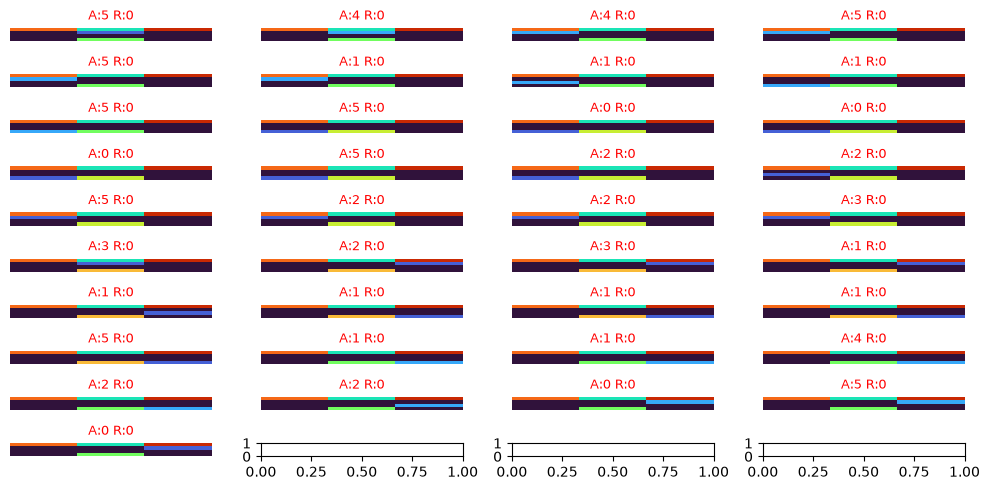

In [20]:
td = 12
anchor = "4-8"
seed_i = 0
ts = "152000"
log= "1"
plot_traj(observation_history125[anchor][f'{log}-{ts}'][td][seed_i], action_history125[anchor][f'{log}-{ts}'][td][seed_i], 
          reward_history125[anchor][f'{log}-{ts}'][td][seed_i], n_rows=10)

# tensorboard

In [93]:
anchors_str = "4-8-12-18"
timestep=200
ent_coeff = 0
g=0.99
log=1
lstm_size = 256

models_folder = "/project_ghent/chronocooked/singleagent/train/bisection_multianchor_cl_models"
if lstm_size is None:
    model_file = f"bisection_multianchor_{anchors_str}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
else:
    model_file = f"bisection_multianchor_{anchors_str}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"

tb_event_file = f"{models_folder}/{model_file}/first_run_0/"

In [52]:
os.listdir(tb_event_file)

['events.out.tfevents.1783531183.5df9a0aa001a.1.0',
 'events.out.tfevents.1783614777.6bba47bb6a12.1.0']

In [47]:
tb_event_file = f"{models_folder}/{model_file}/first_run_0//events.out.tfevents.1783531183.5df9a0aa001a.1"

In [57]:
ea = event_accumulator.EventAccumulator(tb_event_file)
ea.Reload()
eplen = ea.Scalars("rollout/ep_len_mean") 
events = ea.Scalars("rollout/ep_rew_mean")
# eplen_dict = {a_kl.step:a_kl.value for a_kl in eplen if (a_kl.step % 20000 == 0) & (a_kl.step>max_training_ts_env0)}
# return eplen_dict

In [28]:
%load_ext tensorboard

In [94]:
%tensorboard --logdir $tb_event_file